<a href="https://colab.research.google.com/github/thunderhoser/ml4rt/blob/master/NEW_examples_of_unresolvable_uncertainty.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Install compatible versions of TensorFlow and TensorFlow Probability

After running this code cell, you will need to restart the runtime.  But after restarting the runtime, you will *not* need to run this code cell again.

In [1]:
!pip install -U tensorflow==2.15 tensorflow-probability==0.23.0

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.0/61.0 kB 1.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 475.3/475.3 MB 3.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.9/6.9 MB 42.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.7/1.7 MB 22.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.0/1.0 MB 19.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 18.3/18.3 MB 36.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 294.9/294.9 kB 10.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.5/5.5 MB 62.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 442.0/442.0 kB 25.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 78.4/78.4 kB 4.8 MB/s eta 0:00:00
  Attempting uninstall: wrapt
    Found existing installation: wrapt 1.17.2
    Uninstalling wrapt-1.17.2:
      Successfully uninstalled wrapt-1.17.2
  Attempting uninstall: protobuf
    Found existing installati

# Import libraries

In [12]:
%matplotlib inline
import numpy
import keras
import tensorflow
from tensorflow.keras import backend as K
import tensorflow_probability as tf_prob
from tensorflow_probability.python.distributions import \
    kullback_leibler as kl_lib
from matplotlib import pyplot
import matplotlib.colors

# Define constants

In [131]:
SEPARATOR_STRING = '\n\n' + '*' * 50 + '\n\n'

SAVE_FIGURES = False

if SAVE_FIGURES:
    FIGURE_WIDTH_INCHES = 15
    FIGURE_HEIGHT_INCHES = 15
    DEFAULT_FONT_SIZE = 32
else:
    FIGURE_WIDTH_INCHES = 7.5
    FIGURE_HEIGHT_INCHES = 7.5
    DEFAULT_FONT_SIZE = 16

pyplot.rc('font', size=DEFAULT_FONT_SIZE)
pyplot.rc('axes', titlesize=DEFAULT_FONT_SIZE)
pyplot.rc('axes', labelsize=DEFAULT_FONT_SIZE)
pyplot.rc('xtick', labelsize=DEFAULT_FONT_SIZE)
pyplot.rc('ytick', labelsize=DEFAULT_FONT_SIZE)
pyplot.rc('legend', fontsize=DEFAULT_FONT_SIZE)
pyplot.rc('figure', titlesize=DEFAULT_FONT_SIZE)

INSET_HISTOGRAM_FACE_COLOUR = numpy.full(3, 152. / 255)
INSET_HISTOGRAM_EDGE_COLOUR = numpy.full(3, 0.)
INSET_HISTOGRAM_EDGE_WIDTH = 1.

SSRAT_LINE_COLOUR = numpy.array([217, 95, 2], dtype=float) / 255
SSRAT_LINE_WIDTH = 3.

SKILL_LINE_COLOUR = numpy.array([117, 112, 179], dtype=float) / 255
SKILL_LINE_WIDTH = 3.

REFERENCE_LINE_COLOUR = numpy.full(3, 152. / 255)
REFERENCE_LINE_WIDTH = 2.

# Define methods

In [132]:
def target_function_scenarios1and2(x_known_values, x_mult_values, x_add_values):
    """Target function for scenarios 1 and 2.

    This is the correct function for producing y from the three predictors.

    N = number of data points

    :param x_known_values: length-N numpy array with values of predictor
        x_known.
    :param x_mult_values: length-N numpy array with values of predictor
        x_mult.
    :param x_add_values: length-N numpy array with values of predictor
        x_add.
    :return: y_values: length-N numpy array with values of target y.
    """

    y_values = (
        numpy.sin(2 * numpy.pi * x_known_values) * numpy.exp(-1 * x_known_values**2)
        + 0.5 * x_known_values**3
        - numpy.tanh(2 * x_known_values)
    )
    y_values = x_mult_values * y_values + x_add_values

    return y_values


def crps_loss(target_tensor, prediction_tensor):
    """Computes CRPS loss.

    E = number of data examples
    S = ensemble size

    :param target_tensor: E-by-1 tensor of actual values.
    :param prediction_tensor: E-by-1-by-S tensor of predicted values.
    :return: loss_value: Scalar CRPS.
    """

    mae_term = K.mean(K.abs(prediction_tensor - target_tensor), axis=-1)
    mapd_term = K.mean(
        K.abs(
            K.expand_dims(prediction_tensor, -1) -
            K.expand_dims(prediction_tensor, -2)
        ),
        axis=(-2, -1)
    )

    return K.mean(mae_term - 0.5 * mapd_term)


def create_crps_architecture(num_predictors):
    """Creates neural network with CRPS-LF approach to uncertainty quant.

    :param num_predictors: Number of predictor variables.
    :return: model_object: Compiled instance of `keras.models.Model`, ready to
        train.
    """

    l2_object = keras.regularizers.l1_l2(l1=0., l2=1e-6)
    input_layer_object = keras.layers.Input(shape=(num_predictors,))

    # First dense layer.
    current_layer_object = keras.layers.Dense(
        100,
        activation=None,
        use_bias=True,
        kernel_initializer='glorot_uniform',
        bias_initializer='zeros',
        kernel_regularizer=l2_object,
        bias_regularizer=l2_object
    )(input_layer_object)
    current_layer_object = keras.layers.LeakyReLU(alpha=0.2)(
        current_layer_object
    )
    current_layer_object = keras.layers.BatchNormalization(
        axis=-1, momentum=0.99, epsilon=0.001, center=True, scale=True
    )(current_layer_object)

    # Second dense layer.
    current_layer_object = keras.layers.Dense(
        100,
        activation=None,
        use_bias=True,
        kernel_initializer='glorot_uniform',
        bias_initializer='zeros',
        kernel_regularizer=l2_object,
        bias_regularizer=l2_object
    )(current_layer_object)
    current_layer_object = keras.layers.LeakyReLU(alpha=0.2)(
        current_layer_object
    )
    current_layer_object = keras.layers.BatchNormalization(
        axis=-1, momentum=0.99, epsilon=0.001, center=True, scale=True
    )(current_layer_object)

    # Third dense layer.
    current_layer_object = keras.layers.Dense(
        100,
        activation=None,
        use_bias=True,
        kernel_initializer='glorot_uniform',
        bias_initializer='zeros',
        kernel_regularizer=l2_object,
        bias_regularizer=l2_object
    )(current_layer_object)
    current_layer_object = keras.layers.LeakyReLU(alpha=0.2)(
        current_layer_object
    )
    current_layer_object = keras.layers.BatchNormalization(
        axis=-1, momentum=0.99, epsilon=0.001, center=True, scale=True
    )(current_layer_object)

    # Fourth dense layer.
    current_layer_object = keras.layers.Dense(
        100,
        activation=None,
        use_bias=True,
        kernel_initializer='glorot_uniform',
        bias_initializer='zeros',
        kernel_regularizer=l2_object,
        bias_regularizer=l2_object
    )(current_layer_object)
    current_layer_object = keras.layers.LeakyReLU(alpha=0.2)(
        current_layer_object
    )
    current_layer_object = keras.layers.BatchNormalization(
        axis=-1, momentum=0.99, epsilon=0.001, center=True, scale=True
    )(current_layer_object)

    # Output layer (also a dense layer).
    output_layer_object = keras.layers.Dense(
        50,
        activation=None,
        use_bias=True,
        kernel_initializer='glorot_uniform',
        bias_initializer='zeros',
        kernel_regularizer=l2_object,
        bias_regularizer=l2_object
    )(current_layer_object)

    model_object = keras.models.Model(
        inputs=input_layer_object, outputs=output_layer_object
    )
    model_object.compile(
        loss=crps_loss,
        optimizer=keras.optimizers.Lion(),
        metrics=[]
    )

    return model_object


def _get_dense_layer(
        previous_layer_object, num_units, layer_type_string,
        kl_divergence_scaling_factor):
    """Creates dense layer.

    :param previous_layer_object: Previous layer (instance of
        `keras.layers.Layer` or similar).
    :param num_units: Number of units, i.e., output neurons.
    :param layer_type_string: Layer type (options are "point_prediction",
        "flipout", and "reparameterization").
    :param kl_divergence_scaling_factor: Scaling factor for Kullback-Leibler
        divergence.
    :return: layer_object: New dense layer (instance of `keras.layers.Dense` or
        similar).
    """

    assert layer_type_string in ['point_prediction', 'flipout', 'reparameterization']

    if layer_type_string == 'point_prediction':
        return keras.layers.Dense(
            num_units,
            activation=None,
            use_bias=True,
            kernel_initializer='glorot_uniform',
            bias_initializer='zeros'
        )(previous_layer_object)

    if layer_type_string == 'flipout':
        return tf_prob.layers.DenseFlipout(
            units=num_units, activation=None,
            kernel_divergence_fn=(
                lambda q, p, ignore:
                kl_divergence_scaling_factor * kl_lib.kl_divergence(q, p)
            ),
            bias_divergence_fn=(
                lambda q, p, ignore:
                kl_divergence_scaling_factor * kl_lib.kl_divergence(q, p)
            )
        )(previous_layer_object)

    return tf_prob.layers.DenseReparameterization(
        units=num_units, activation=None,
        kernel_divergence_fn=(
            lambda q, p, ignore:
            kl_divergence_scaling_factor * kl_lib.kl_divergence(q, p)
        ),
        bias_divergence_fn=(
            lambda q, p, ignore:
            kl_divergence_scaling_factor * kl_lib.kl_divergence(q, p)
        )
    )(previous_layer_object)


def create_bnn_crps_architecture(num_predictors, num_training_examples,
                                 num_bayesian_layers, use_flipout):
    """Creates neural network with BNN/CRPS approach to uncertainty quant.

    :param num_predictors: Number of predictor variables.
    :param num_training_examples: Number of training examples.
    :param num_bayesian_layers: Number of Bayesian layers.
    :param use_flipout: Boolean flag.  If True (False), will use flipout
        (reparameterization) for Bayesian layers.
    :return: model_object: Compiled instance of `keras.models.Model`, ready to
        train.
    """

    assert num_bayesian_layers > 0
    kl_divergence_scaling_factor = num_training_examples ** -1
    bayesian_layer_type_string = 'flipout' if use_flipout else 'reparameterization'

    input_layer_object = keras.layers.Input(shape=(num_predictors,))

    # First dense layer.
    current_layer_object = _get_dense_layer(
        previous_layer_object=input_layer_object,
        num_units=100,
        layer_type_string=(
            'point_prediction' if num_bayesian_layers < 5
            else bayesian_layer_type_string
        ),
        kl_divergence_scaling_factor=kl_divergence_scaling_factor
    )
    current_layer_object = keras.layers.LeakyReLU(alpha=0.2)(
        current_layer_object
    )
    current_layer_object = keras.layers.BatchNormalization(
        axis=-1, momentum=0.99, epsilon=0.001, center=True, scale=True
    )(current_layer_object)

    # Second dense layer.
    current_layer_object = _get_dense_layer(
        previous_layer_object=current_layer_object,
        num_units=100,
        layer_type_string=(
            'point_prediction' if num_bayesian_layers < 4
            else bayesian_layer_type_string
        ),
        kl_divergence_scaling_factor=kl_divergence_scaling_factor
    )
    current_layer_object = keras.layers.LeakyReLU(alpha=0.2)(
        current_layer_object
    )
    current_layer_object = keras.layers.BatchNormalization(
        axis=-1, momentum=0.99, epsilon=0.001, center=True, scale=True
    )(current_layer_object)

    # Third dense layer.
    current_layer_object = _get_dense_layer(
        previous_layer_object=current_layer_object,
        num_units=100,
        layer_type_string=(
            'point_prediction' if num_bayesian_layers < 3
            else bayesian_layer_type_string
        ),
        kl_divergence_scaling_factor=kl_divergence_scaling_factor
    )
    current_layer_object = keras.layers.LeakyReLU(alpha=0.2)(
        current_layer_object
    )
    current_layer_object = keras.layers.BatchNormalization(
        axis=-1, momentum=0.99, epsilon=0.001, center=True, scale=True
    )(current_layer_object)

    # Fourth dense layer.
    current_layer_object = _get_dense_layer(
        previous_layer_object=current_layer_object,
        num_units=100,
        layer_type_string=(
            'point_prediction' if num_bayesian_layers < 2
            else bayesian_layer_type_string
        ),
        kl_divergence_scaling_factor=kl_divergence_scaling_factor
    )
    current_layer_object = keras.layers.LeakyReLU(alpha=0.2)(
        current_layer_object
    )
    current_layer_object = keras.layers.BatchNormalization(
        axis=-1, momentum=0.99, epsilon=0.001, center=True, scale=True
    )(current_layer_object)

    # Output layer (also a dense layer).
    output_layer_object = _get_dense_layer(
        previous_layer_object=current_layer_object,
        num_units=50,
        layer_type_string=bayesian_layer_type_string,
        kl_divergence_scaling_factor=kl_divergence_scaling_factor
    )

    model_object = keras.models.Model(
        inputs=input_layer_object, outputs=output_layer_object
    )
    model_object.compile(
        loss=crps_loss,
        optimizer=keras.optimizers.Lion(),
        metrics=[]
    )

    return model_object


def _get_ssrat_colour_scheme(max_colour_value):
    """Returns colour scheme for spread-skill ratio (SSRAT).

    :param colour_map_name: Name of colour scheme (must be accepted by
        `matplotlib.pyplot.get_cmap`).
    :return: colour_map_object: Colour map (instance of `matplotlib.pyplot.cm`).
    :return: colour_norm_object: Colour-normalizer (maps from data space to
        colour-bar space, which goes from 0...1).  This is an instance of
        `matplotlib.colors.Normalize`.
    """

    orig_colour_map_object = pyplot.get_cmap('seismic')

    negative_values = numpy.linspace(0, 1, num=1001, dtype=float)
    positive_values = numpy.linspace(1, max_colour_value, num=1001, dtype=float)
    bias_values = numpy.concatenate((negative_values, positive_values))

    normalized_values = numpy.linspace(0, 1, num=len(bias_values), dtype=float)
    rgb_matrix = orig_colour_map_object(normalized_values)[:, :-1]

    colour_map_object = matplotlib.colors.ListedColormap(rgb_matrix)
    colour_norm_object = matplotlib.colors.BoundaryNorm(
        bias_values, colour_map_object.N
    )

    return colour_map_object, colour_norm_object


def _finite_percentile(input_array, percentile_level):
    """Takes percentile of input array, considering only finite values.

    :param input_array: numpy array.
    :param percentile_level: Percentile level, ranging from 0...100.
    :return: output_percentile: Percentile value.
    """

    return numpy.percentile(
        input_array[numpy.isfinite(input_array)], percentile_level
    )


def bin_spread_and_skill_vs_two_vars(prediction_matrix, target_matrix,
                                     predictor_matrix, num_bins,
                                     predictor_matrix_for_bin_limits=None):
    """Bins spread snd 'skill' (RMSE) with respect to two predictor variables.

    E = number of data examples
    S = ensemble size
    B = number of bins

    :param prediction_matrix: E-by-S numpy array of ensemble predictions.
    :param target_matrix: E-by-1 numpy array of target values.
    :param predictor_matrix: E-by-2 numpy array of predictor values.
    :param num_bins: Number of bins (scalar) -- will be applied to each
        predictor variable.
    :param predictor_matrix_for_bin_limits: E-by-2 numpy array of predictor
        values, used to create bin limits.
    :return: binned_skill_matrix: B-by-B numpy array of "skill" values (RMSE of
        ensemble mean).
    :return: binned_spread_matrix: B-by-B numpy array of spread values (mean
        standard deviation of ensemble members).
    :return: binned_example_count_matrix: B-by-B numpy array with number of data
        examples falling into each bin.
    :return: x1_bin_edges: length-(B + 1) numpy array of bin edges for x1.
    :return: x2_bin_edges: length-(B + 1) numpy array of bin edges for x2.
    """

    x1_values = predictor_matrix[:, 0]
    x1_bin_edges = numpy.linspace(
        numpy.min(predictor_matrix_for_bin_limits[:, 0]),
        numpy.max(predictor_matrix_for_bin_limits[:, 0]),
        num=num_bins + 1, dtype=float
    )

    x2_values = predictor_matrix[:, 1]
    x2_bin_edges = numpy.linspace(
        numpy.min(predictor_matrix_for_bin_limits[:, 1]),
        numpy.max(predictor_matrix_for_bin_limits[:, 1]),
        num=num_bins + 1, dtype=float
    )

    binned_skill_matrix = numpy.full(
        (num_bins, num_bins), numpy.nan
    )
    binned_spread_matrix = numpy.full(
        (num_bins, num_bins), numpy.nan
    )
    binned_example_count_matrix = numpy.full(
        (num_bins, num_bins), 0, dtype=int
    )

    for i in range(num_bins):
        print('Have sorted examples into {0:d} of {1:d} bins...'.format(
            i * num_bins, num_bins * num_bins
        ))

        for j in range(num_bins):
            if i == num_bins - 1:
                first_flags = x1_values >= x1_bin_edges[i]
            else:
                first_flags =  numpy.logical_and(
                    x1_values >= x1_bin_edges[i],
                    x1_values < x1_bin_edges[i + 1]
                )

            if numpy.sum(first_flags) == 0:
                continue

            if j == NUM_BINS - 1:
                second_flags = x2_values >= x2_bin_edges[j]
            else:
                second_flags = numpy.logical_and(
                    x2_values >= x2_bin_edges[j],
                    x2_values < x2_bin_edges[j + 1]
                )

            if numpy.sum(second_flags) == 0:
                continue

            good_indices = numpy.where(numpy.logical_and(
                first_flags, second_flags
            ))[0]
            if len(good_indices) == 0:
                continue

            binned_example_count_matrix[i, j] = len(good_indices)

            these_ensemble_means = numpy.mean(
                prediction_matrix[good_indices, :], axis=-1
            )
            these_ensemble_stdevs = numpy.std(
                prediction_matrix[good_indices, :], axis=-1, ddof=1
            )
            these_squared_errors = (
                these_ensemble_means - target_matrix[good_indices, 0]
            ) ** 2

            binned_skill_matrix[i, j] = numpy.sqrt(
                numpy.mean(these_squared_errors)
            )
            binned_spread_matrix[i, j] = numpy.sqrt(
                numpy.mean(these_ensemble_stdevs ** 2)
            )

    return (
        binned_skill_matrix, binned_spread_matrix, binned_example_count_matrix,
        x1_bin_edges, x2_bin_edges
    )


def plot_skill_or_ssrat_vs_two_vars(
        binned_skill_matrix, binned_spread_matrix, binned_example_count_matrix,
        x1_bin_edges, x2_bin_edges, plot_ssrat):
    """Plots either 'skill' (RMSE) or SSRAT (spread-skill ratio) vs. x1 and x2.

    A = number of bins for x1
    B = number of bins for x2

    :param binned_skill_matrix: A-by-B numpy array of "skill" values (RMSE of
        ensemble mean)
    :param binned_spread_matrix: A-by-B numpy array of spread values (mean
        standard deviation of ensemble members).
    :param binned_example_count_matrix: A-by-B numpy array with number of data
        examples falling into each bin.
    :param x1_bin_edges: length-(A + 1) numpy array of bin edges for x1.
    :param x2_bin_edges: length-(B + 1) numpy array of bin edges for x2.
    :param plot_ssrat: Boolean flag.  If True (False), will plot SSRAT (skill).
    :return: figure_object: Figure handle (instance of
        `matplotlib.figure.Figure`).
    :return: axes_object: Axes handle (instance of
        `matplotlib.axes._subplots.AxesSubplot`).
    """

    figure_object, axes_object = pyplot.subplots(
        1, 1, figsize=(FIGURE_WIDTH_INCHES, FIGURE_HEIGHT_INCHES)
    )

    if plot_ssrat:
        matrix_to_plot = binned_spread_matrix / binned_skill_matrix
        this_offset = _finite_percentile(
            numpy.absolute(matrix_to_plot - 1.), 99.
        )
        colour_map_object, colour_norm_object = (
            _get_ssrat_colour_scheme(max_colour_value=1. + this_offset)
        )

        title_string = 'Spread-skill ratio'
    else:
        matrix_to_plot = binned_skill_matrix + 0.
        colour_map_object = pyplot.get_cmap('viridis')
        colour_norm_object = pyplot.Normalize(
            vmin=numpy.nanmin(binned_skill_matrix),
            vmax=numpy.nanmax(binned_skill_matrix)
        )

        title_string = '"Skill" (RMSE of ensemble mean)'

    # x1_matrix, x2_matrix = numpy.meshgrid(x1_bin_edges, x2_bin_edges)
    # nan_row = numpy.full((1, matrix_to_plot.shape[1]), numpy.nan)
    # matrix_to_plot = numpy.vstack([matrix_to_plot, nan_row])
    # nan_column = numpy.full((matrix_to_plot.shape[0], 1), numpy.nan)
    # matrix_to_plot = numpy.hstack([matrix_to_plot, nan_column])

    x1_bin_centers = (x1_bin_edges[:-1] + x1_bin_edges[1:]) / 2.
    x2_bin_centers = (x2_bin_edges[:-1] + x2_bin_edges[1:]) / 2.
    x1_matrix, x2_matrix = numpy.meshgrid(x1_bin_centers, x2_bin_centers)

    axes_object.pcolor(
        x1_matrix, x2_matrix, matrix_to_plot,
        cmap=colour_map_object,
        norm=colour_norm_object,
        edgecolors='None'
    )

    these_diffs = numpy.absolute(binned_spread_matrix - binned_skill_matrix)
    these_diffs[numpy.isnan(these_diffs)] = 0.
    overall_ssrel = numpy.average(
        these_diffs, weights=binned_example_count_matrix
    )

    these_rmse = binned_skill_matrix + 0.
    these_rmse[numpy.isnan(these_rmse)] = 0.
    overall_rmse = numpy.sqrt(numpy.average(
        these_rmse ** 2, weights=binned_example_count_matrix
    ))

    these_stdev = binned_spread_matrix + 0.
    these_stdev[numpy.isnan(these_stdev)] = 0.
    overall_stdev = numpy.sqrt(numpy.average(
        these_stdev ** 2, weights=binned_example_count_matrix
    ))

    overall_ssrat = overall_stdev / overall_rmse

    if plot_ssrat:
        title_string += (
            '\nOverall SSRAT = {0:.2f}; overall SSREL = {1:.2f}'
        ).format(
            overall_ssrat, overall_ssrel
        )
    else:
        title_string += '\nOverall RMSE = {0:.2f}'.format(overall_rmse)

    axes_object.set_title(title_string)

    plot_colour_bar(
        axes_object_or_matrix=axes_object,
        data_matrix=matrix_to_plot,
        colour_map_object=colour_map_object,
        colour_norm_object=colour_norm_object,
        orientation_string='vertical',
        extend_min=False,
        extend_max=False
    )

    return figure_object, axes_object


def target_function_scenario3(x1_values, x2_values):
    """Target function for scenario 3.

    This is the correct function for producing y from x_1 and x_2.

    :param x1_values: numpy array with values of predictor x_1.
    :param x2_values: numpy array (same shape) with values of predictor x_2.
    :return: y_values: numpy array (same shape) with values of target y.
    """

    y_values_base = (
        numpy.sin(3 * x1_values) * numpy.cos(3 * x2_values)
        + 0.2 * numpy.sin(5 * x1_values * x2_values)
    )
    y_values_envelope = 1 + 0.5 * (x1_values**2 + x2_values**2)
    return y_values_base * y_values_envelope


def plot_colour_bar(
        axes_object_or_matrix, data_matrix, colour_map_object,
        colour_norm_object, orientation_string='vertical',
        padding=None, extend_min=True, extend_max=True,
        fraction_of_axis_length=1., font_size=DEFAULT_FONT_SIZE):
    """Plots colour bar.

    :param axes_object_or_matrix: Either one axis handle (instance of
        `matplotlib.axes._subplots.AxesSubplot`) or a numpy array thereof.
    :param data_matrix: numpy array of values to which the colour map applies.
    :param colour_map_object: Colour map (instance of `matplotlib.pyplot.cm` or
        similar).
    :param colour_norm_object: Colour normalization (maps from data space to
        colour-bar space, which goes from 0...1).  This should be an instance of
        `matplotlib.pyplot.Normalize` or similar.
    :param orientation_string: Orientation ("vertical" or "horizontal").
    :param padding: Padding between colour bar and main plot (in range 0...1).
        To use the default (there are different defaults for vertical and horiz
        colour bars), leave this alone.
    :param extend_min: Boolean flag.  If True, values below the minimum
        specified by `colour_norm_object` are possible, so the colour bar will
        be plotted with an arrow at the bottom.
    :param extend_max: Boolean flag.  If True, values above the max specified by
        `colour_norm_object` are possible, so the colour bar will be plotted
        with an arrow at the top.
    :param fraction_of_axis_length: The colour bar will take up this fraction of
        the axis length (x-axis if orientation_string = "horizontal", y-axis if
        orientation_string = "vertical").
    :param font_size: Font size for tick marks on colour bar.
    :return: colour_bar_object: Colour-bar handle (instance of
        `matplotlib.pyplot.colorbar`).
    """

    scalar_mappable_object = pyplot.cm.ScalarMappable(
        cmap=colour_map_object, norm=colour_norm_object
    )
    scalar_mappable_object.set_array(data_matrix)

    if extend_min and extend_max:
        extend_arg = 'both'
    elif extend_min:
        extend_arg = 'min'
    elif extend_max:
        extend_arg = 'max'
    else:
        extend_arg = 'neither'

    if padding is None:
        if orientation_string == 'horizontal':
            padding = 0.075
        else:
            padding = 0.05

    if isinstance(axes_object_or_matrix, numpy.ndarray):
        axes_arg = axes_object_or_matrix.ravel().tolist()
    else:
        axes_arg = axes_object_or_matrix

    colour_bar_object = pyplot.colorbar(
        ax=axes_arg,
        mappable=scalar_mappable_object,
        orientation=orientation_string,
        pad=padding,
        extend=extend_arg,
        shrink=fraction_of_axis_length
    )

    colour_bar_object.ax.tick_params(labelsize=font_size)

    if orientation_string == 'horizontal':
        colour_bar_object.ax.set_xticklabels(
            colour_bar_object.ax.get_xticklabels(), rotation=90
        )

    return colour_bar_object

# Scenario 1: Missing variable

In this scenario, the target value is a function of three variables ($x_{\textrm{known}}$, $x_{\textrm{mult}}$, and $x_{\textrm{add}}$) but the model uses only $x_{\textrm{known}}$ as a predictor.  Thus, any uncertainty related to $x_{\textrm{mult}}$ and $x_{\textrm{add}}$ is unresolvable.
 Mathematically:

$y_{\textrm{true}} = f(x_{\textrm{known}}, x_{\textrm{mult}}, x_{\textrm{add}})$
<br />
$\vec{y}_{\textrm{pred}} = \hat{f}(x_{\textrm{known}})$

## Data exploration

Specifically, $y_{\textrm{true}} = x_{\textrm{mult}}\textrm{ }g(x_{\textrm{known}}) + x_{\textrm{add}}$, where $g$ is a complicated non-linear function:

$g = \textrm{sin}(2 \pi x_{\textrm{known}}) \textrm{ exp}(-x_{\textrm{known}}^2) + \frac{1}{2}x_{\textrm{known}}^3 - \textrm{tanh}(2x_{\textrm{known}})$
<br />
<br />
The next code cell shows the relationship between $y_{\textrm{true}}$ and the predictors under two scenarios:
 - When $x_{\textrm{mult}} = 1$ everywhere
 - When $x_{\textrm{add}} = 0$ everywhere

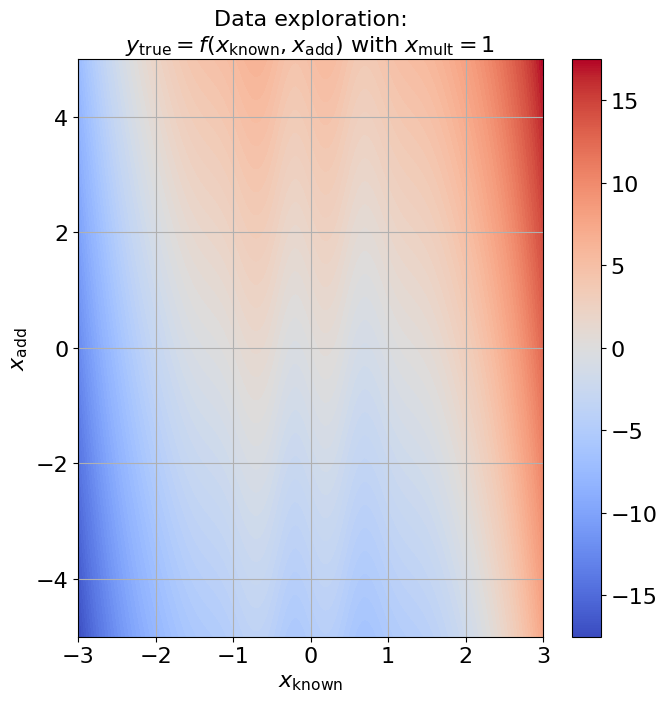

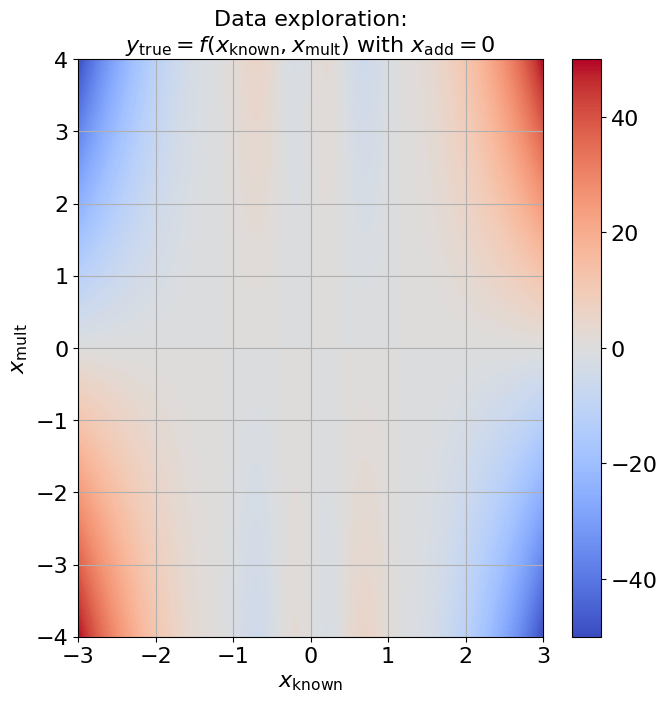

In [105]:
NUM_EXAMPLES_PER_AXIS = 1000

# Create a dataset with x_mult = 1 everywhere.
unique_x_known_values = numpy.linspace(
    -3, 3, num=NUM_EXAMPLES_PER_AXIS, dtype=float
)
unique_x_add_values = numpy.linspace(
    -5, 5, num=NUM_EXAMPLES_PER_AXIS, dtype=float
)
x_known_matrix, x_add_matrix = numpy.meshgrid(
    unique_x_known_values, unique_x_add_values
)
y_matrix = target_function_scenarios1and2(
    x_known_values=x_known_matrix,
    x_mult_values=numpy.full(x_known_matrix.shape, 1.),
    x_add_values=x_add_matrix
)

figure_object, axes_object = pyplot.subplots(
    1, 1, figsize=(FIGURE_WIDTH_INCHES, FIGURE_HEIGHT_INCHES)
)

colour_map_object = pyplot.get_cmap('coolwarm')
colour_norm_object = pyplot.Normalize(
    vmin=-1 * numpy.max(numpy.absolute(y_matrix)),
    vmax=numpy.max(numpy.absolute(y_matrix))
)
axes_object.contourf(
    x_known_matrix, x_add_matrix, y_matrix,
    levels=100,
    cmap=colour_map_object,
    norm=colour_norm_object
)

axes_object.set_xlabel(r'$x_{\text{known}}$')
axes_object.set_ylabel(r'$x_{\text{add}}$')
axes_object.set_title(
    'Data exploration:\n' +
    r'$y_{\text{true}} = f(x_{\text{known}}, x_{\text{add}})$ with $x_{\text{mult}} = 1$'
)
axes_object.grid(True)

plot_colour_bar(
    axes_object_or_matrix=axes_object,
    data_matrix=y_matrix,
    colour_map_object=colour_map_object,
    colour_norm_object=colour_norm_object,
    orientation_string='vertical',
    extend_min=False,
    extend_max=False
)

if SAVE_FIGURES:
    output_file_name = 'scenario1_data_exploration1.jpg'
    print('Saving figure to: "{0:s}"...'.format(output_file_name))
    figure_object.savefig(
        output_file_name, dpi=600, pad_inches=0, bbox_inches='tight'
    )
    pyplot.close(figure_object)

# Create a dataset with x_add = 0 everywhere.
unique_x_known_values = numpy.linspace(
    -3, 3, num=NUM_EXAMPLES_PER_AXIS, dtype=float
)
unique_x_mult_values = numpy.linspace(
    -4, 4, num=NUM_EXAMPLES_PER_AXIS, dtype=float
)
x_known_matrix, x_mult_matrix = numpy.meshgrid(
    unique_x_known_values, unique_x_mult_values
)
y_matrix = target_function_scenarios1and2(
    x_known_values=x_known_matrix,
    x_mult_values=x_mult_matrix,
    x_add_values=numpy.full(x_known_matrix.shape, 0.)
)

figure_object, axes_object = pyplot.subplots(
    1, 1, figsize=(FIGURE_WIDTH_INCHES, FIGURE_HEIGHT_INCHES)
)

colour_map_object = pyplot.get_cmap('coolwarm')
colour_norm_object = pyplot.Normalize(
    vmin=-1 * numpy.max(numpy.absolute(y_matrix)),
    vmax=numpy.max(numpy.absolute(y_matrix))
)
axes_object.contourf(
    x_known_matrix, x_mult_matrix, y_matrix,
    levels=100,
    cmap=colour_map_object,
    norm=colour_norm_object
)

axes_object.set_xlabel(r'$x_{\text{known}}$')
axes_object.set_ylabel(r'$x_{\text{mult}}$')
axes_object.set_title(
    'Data exploration:\n' +
    r'$y_{\text{true}} = f(x_{\text{known}}, x_{\text{mult}})$ with $x_{\text{add}} = 0$'
)
axes_object.grid(True)

plot_colour_bar(
    axes_object_or_matrix=axes_object,
    data_matrix=y_matrix,
    colour_map_object=colour_map_object,
    colour_norm_object=colour_norm_object,
    orientation_string='vertical',
    extend_min=False,
    extend_max=False
)

if SAVE_FIGURES:
    output_file_name = 'scenario1_data_exploration2.jpg'
    print('Saving figure to: "{0:s}"...'.format(output_file_name))
    figure_object.savefig(
        output_file_name, dpi=600, pad_inches=0, bbox_inches='tight'
    )
    pyplot.close(figure_object)

## Create the BNN/CRPS architecture

The next code cell creates a neural network with the BNN/CRPS architecture -- *i.e.*, using the hybrid BNN/CRPS method for uncertainty quantification.

In [106]:
model_object_scenario1 = create_bnn_crps_architecture(
    num_predictors=1,
    num_training_examples=10000,
    num_bayesian_layers=3,
    use_flipout=False
)
model_object_scenario1.summary()

/usr/local/lib/python3.11/dist-packages/tensorflow_probability/python/layers/util.py:98: UserWarning: `layer.add_variable` is deprecated and will be removed in a future version. Please use the `layer.add_weight()` method instead.
  loc = add_variable_fn(
/usr/local/lib/python3.11/dist-packages/tensorflow_probability/python/layers/util.py:108: UserWarning: `layer.add_variable` is deprecated and will be removed in a future version. Please use the `layer.add_weight()` method instead.
  untransformed_scale = add_variable_fn(


Model: "model_15"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 input_16 (InputLayer)       [(None, 1)]               0         
                                                                 
 dense_30 (Dense)            (None, 100)               200       
                                                                 
 leaky_re_lu_60 (LeakyReLU)  (None, 100)               0         
                                                                 
 batch_normalization_60 (Ba  (None, 100)               400       
 tchNormalization)                                               
                                                                 
 dense_31 (Dense)            (None, 100)               10100     
                                                                 
 leaky_re_lu_61 (LeakyReLU)  (None, 100)               0         
                                                          

## Train the model with one predictor (no $x_{\textrm{mult}}$ or $x_{\textrm{add}}$)

The next code cell trains a BNN/CRPS neural network to predict $y$ from $x_{\textrm{known}}$; the neural network uses only $x_{\textrm{known}}$ as a predictor, so crucial information from $x_{\textrm{mult}}$ and $x_{\textrm{add}}$ is not available.

In [107]:
NUM_EXAMPLES = 250000

x_known_values = numpy.linspace(-3, 3, num=NUM_EXAMPLES, dtype=float)
training_x_mult_values = numpy.random.uniform(
    low=-10., high=10., size=NUM_EXAMPLES
)
training_x_add_values = numpy.random.uniform(
    low=-10., high=10., size=NUM_EXAMPLES
)
training_y_values = target_function_scenarios1and2(
    x_known_values=x_known_values,
    x_mult_values=training_x_mult_values,
    x_add_values=training_x_add_values
)

training_predictor_matrix = numpy.transpose(numpy.vstack(
    [x_known_values, training_x_mult_values, training_x_add_values]
))
training_target_matrix = numpy.expand_dims(training_y_values, axis=-1)

validation_x_mult_values = numpy.random.uniform(
    low=-10., high=10., size=NUM_EXAMPLES
)
validation_x_add_values = numpy.random.uniform(
    low=-10., high=10., size=NUM_EXAMPLES
)
validation_y_values = target_function_scenarios1and2(
    x_known_values=x_known_values,
    x_mult_values=validation_x_mult_values,
    x_add_values=validation_x_add_values
)

validation_predictor_matrix = numpy.transpose(numpy.vstack(
    [x_known_values, validation_x_mult_values, validation_x_add_values]
))
validation_target_matrix = numpy.expand_dims(validation_y_values, axis=-1)

model_object = create_bnn_crps_architecture(
    num_predictors=1,
    num_training_examples=NUM_EXAMPLES,
    num_bayesian_layers=3,
    use_flipout=False
)
model_object.summary()

model_object.fit(
    x=training_predictor_matrix[:, :1],
    y=training_target_matrix,
    batch_size=100,
    epochs=100,
    initial_epoch=0,
    steps_per_epoch=100,
    shuffle=True,
    verbose=1,
    validation_data=(
        validation_predictor_matrix[:, :1], validation_target_matrix
    ),
    validation_steps=100
)

Model: "model_16"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 input_17 (InputLayer)       [(None, 1)]               0         
                                                                 
 dense_32 (Dense)            (None, 100)               200       
                                                                 
 leaky_re_lu_64 (LeakyReLU)  (None, 100)               0         
                                                                 
 batch_normalization_64 (Ba  (None, 100)               400       
 tchNormalization)                                               
                                                                 
 dense_33 (Dense)            (None, 100)               10100     
                                                                 
 leaky_re_lu_65 (LeakyReLU)  (None, 100)               0         
                                                          

## Evaluate the model on validation data

The next code cell evaluates the BNN/CRPS neural network on validation data.

As we exit the trivial region of the predictor space (where $x_{\textrm{mult}}$ = 1 and $x_{\textrm{add}}$ = 0), the model's error (RMSE of the ensemble mean) increases, but spread-skill ratio decreases.  In other words, the model makes increasingly wrong predictions but with high confidence.  At a certain point (a certain distance away from $x_{\textrm{mult}}$ = 1 and $x_{\textrm{add}}$ = 0, depending on the application), these highly confident wrong predictions would be considered **catastrophic errors**.

Shape of validation_prediction_matrix = (250000, 500)
Have sorted examples into 0 of 10000 bins...
Have sorted examples into 100 of 10000 bins...
Have sorted examples into 200 of 10000 bins...
Have sorted examples into 300 of 10000 bins...
Have sorted examples into 400 of 10000 bins...
Have sorted examples into 500 of 10000 bins...
Have sorted examples into 600 of 10000 bins...
Have sorted examples into 700 of 10000 bins...
Have sorted examples into 800 of 10000 bins...
Have sorted examples into 900 of 10000 bins...
Have sorted examples into 1000 of 10000 bins...
Have sorted examples into 1100 of 10000 bins...
Have sorted examples into 1200 of 10000 bins...
Have sorted examples into 1300 of 10000 bins...
Have sorted examples into 1400 of 10000 bins...
Have sorted examples into 1500 of 10000 bins...
Have sorted examples into 1600 of 10000 bins...
Have sorted examples into 1700 of 10000 bins...
Have sorted examples into 1800 of 10000 bins...
Have sorted examples into 1900 of 10000 bins..

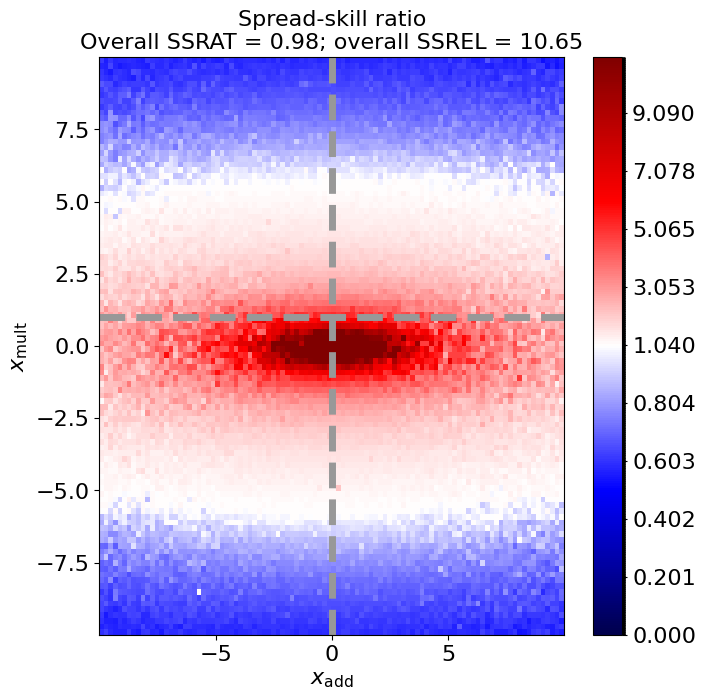

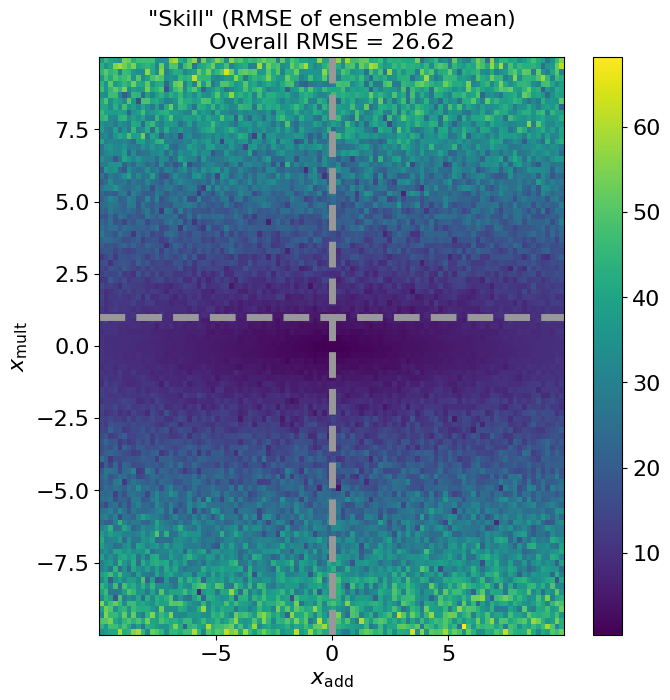

In [108]:
NUM_ITERATIONS = 10
validation_prediction_matrix = numpy.array([])

for i in range(NUM_ITERATIONS):
    new_prediction_matrix = model_object.predict_on_batch(
        validation_predictor_matrix[:, :1]
    )

    if i == 0:
        validation_prediction_matrix = new_prediction_matrix + 0.
    else:
        validation_prediction_matrix = numpy.concatenate(
            [validation_prediction_matrix, new_prediction_matrix], axis=-1
        )

print('Shape of validation_prediction_matrix = {0:s}'.format(
    str(validation_prediction_matrix.shape)
))

(
    binned_skill_matrix, binned_spread_matrix, binned_example_count_matrix,
    x_mult_bin_edges, x_add_bin_edges
) = bin_spread_and_skill_vs_two_vars(
    prediction_matrix=validation_prediction_matrix,
    target_matrix=validation_target_matrix,
    predictor_matrix=validation_predictor_matrix[:, 1:],
    num_bins=100,
    predictor_matrix_for_bin_limits=validation_predictor_matrix[:, 1:]
)

figure_object, axes_object = plot_skill_or_ssrat_vs_two_vars(
    binned_skill_matrix=binned_skill_matrix,
    binned_spread_matrix=binned_spread_matrix,
    binned_example_count_matrix=binned_example_count_matrix,
    x1_bin_edges=x_mult_bin_edges,
    x2_bin_edges=x_add_bin_edges,
    plot_ssrat=True
)
axes_object.set_ylabel(r'$x_{\text{mult}}$')
axes_object.set_xlabel(r'$x_{\text{add}}$')
x_limits = axes_object.get_xlim()
y_limits = axes_object.get_ylim()
axes_object.plot(
    numpy.array(x_limits), numpy.array([1., 1.]),
    color=REFERENCE_LINE_COLOUR,
    linestyle='dashed',
    linewidth=5
)
axes_object.plot(
    numpy.array([0., 0.]), numpy.array(y_limits),
    color=REFERENCE_LINE_COLOUR,
    linestyle='dashed',
    linewidth=5
)

if SAVE_FIGURES:
    output_file_name = 'scenario1_ssrat.jpg'
    print('Saving figure to: "{0:s}"...'.format(output_file_name))
    figure_object.savefig(
        output_file_name, dpi=600, pad_inches=0, bbox_inches='tight'
    )
    pyplot.close(figure_object)

figure_object, axes_object = plot_skill_or_ssrat_vs_two_vars(
    binned_skill_matrix=binned_skill_matrix,
    binned_spread_matrix=binned_spread_matrix,
    binned_example_count_matrix=binned_example_count_matrix,
    x1_bin_edges=x_mult_bin_edges,
    x2_bin_edges=x_add_bin_edges,
    plot_ssrat=False
)
axes_object.set_ylabel(r'$x_{\text{mult}}$')
axes_object.set_xlabel(r'$x_{\text{add}}$')
x_limits = axes_object.get_xlim()
y_limits = axes_object.get_ylim()
axes_object.plot(
    numpy.array(x_limits), numpy.array([1., 1.]),
    color=REFERENCE_LINE_COLOUR,
    linestyle='dashed',
    linewidth=5
)
axes_object.plot(
    numpy.array([0., 0.]), numpy.array(y_limits),
    color=REFERENCE_LINE_COLOUR,
    linestyle='dashed',
    linewidth=5
)

if SAVE_FIGURES:
    output_file_name = 'scenario1_skill.jpg'
    print('Saving figure to: "{0:s}"...'.format(output_file_name))
    figure_object.savefig(
        output_file_name, dpi=600, pad_inches=0, bbox_inches='tight'
    )
    pyplot.close(figure_object)

## Evaluate the model on dummy data (targets have no relationship with $x_{\textrm{mult}}$ or $x_{\textrm{add}}$)

The next code cell evaluates the BNN/CRPS neural network on a dummy validation set, where the target value $y_{\textrm{true}}$ no longer depends on $x_{\textrm{mult}}$ or $x_{\textrm{add}}$.  Thus, instead of

$y_{\textrm{true}} = x_{\textrm{mult}}\textrm{ }g(x_{\textrm{known}}) + x_{\textrm{add}}$,

the true target function is

$y_{\textrm{true}} = g(x_{\textrm{known}})$.
<br />
<br />
In this case, both the true function and our neural-network-estimated function depend only on $x_{\textrm{known}}$.  Thus, our neural network is well equipped to handle this dummy dataset and performs quite well (albeit with a high SSRAT).  Thus, we can conclude that the poor performance on the *real* validation set (above) is caused by non-trivial values of the missing variables ($x_{\textrm{mult}} \neq 1$ and $x_{\textrm{add}} \neq 0$) in the real validation set.

Shape of dummy_prediction_matrix = (250000, 500)
Have sorted examples into 0 of 10000 bins...
Have sorted examples into 100 of 10000 bins...
Have sorted examples into 200 of 10000 bins...
Have sorted examples into 300 of 10000 bins...
Have sorted examples into 400 of 10000 bins...
Have sorted examples into 500 of 10000 bins...
Have sorted examples into 600 of 10000 bins...
Have sorted examples into 700 of 10000 bins...
Have sorted examples into 800 of 10000 bins...
Have sorted examples into 900 of 10000 bins...
Have sorted examples into 1000 of 10000 bins...
Have sorted examples into 1100 of 10000 bins...
Have sorted examples into 1200 of 10000 bins...
Have sorted examples into 1300 of 10000 bins...
Have sorted examples into 1400 of 10000 bins...
Have sorted examples into 1500 of 10000 bins...
Have sorted examples into 1600 of 10000 bins...
Have sorted examples into 1700 of 10000 bins...
Have sorted examples into 1800 of 10000 bins...
Have sorted examples into 1900 of 10000 bins...
Hav

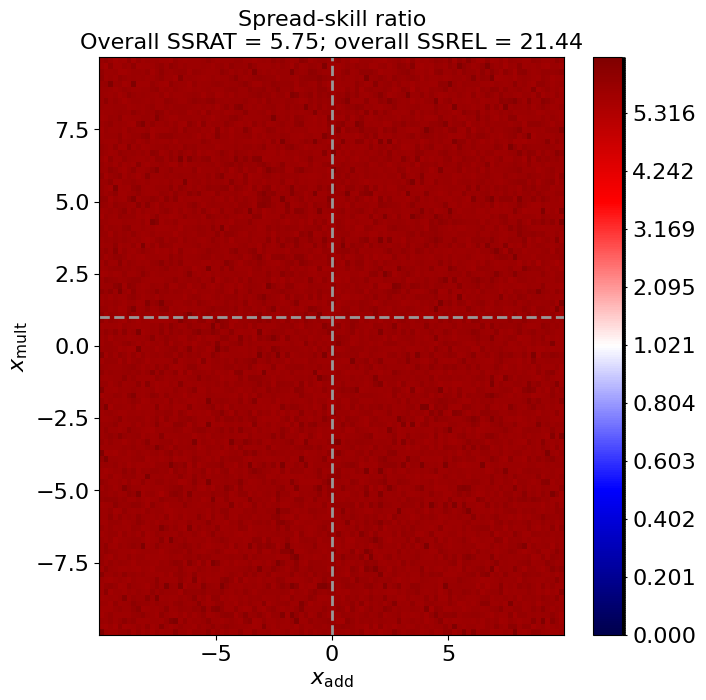

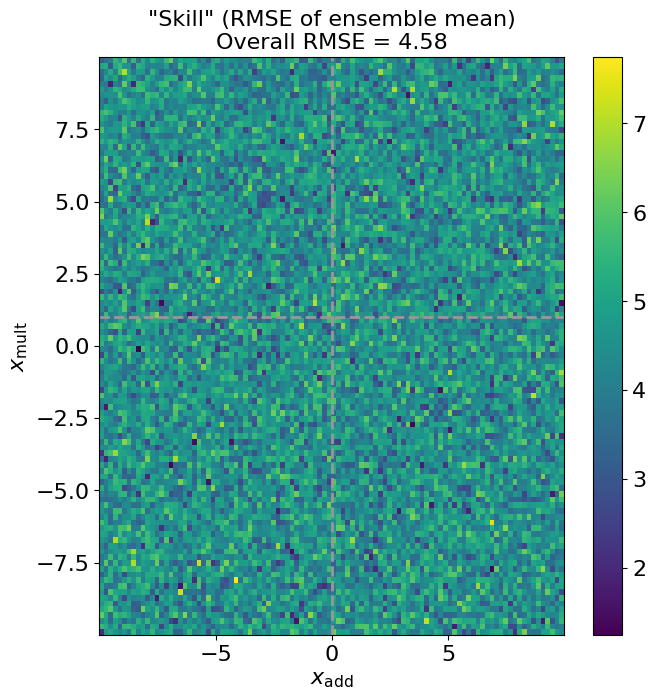

In [109]:
dummy_x_mult_values = numpy.random.uniform(
    low=-10., high=10., size=NUM_EXAMPLES
)
dummy_x_add_values = numpy.random.uniform(
    low=-10., high=10., size=NUM_EXAMPLES
)
dummy_y_values = target_function_scenarios1and2(
    x_known_values=x_known_values,
    x_mult_values=numpy.full(x_known_values.shape, 1.),
    x_add_values=numpy.full(x_known_values.shape, 0.)
)

dummy_predictor_matrix = numpy.transpose(
    numpy.vstack([x_known_values, dummy_x_mult_values, dummy_x_add_values])
)
dummy_target_matrix = numpy.expand_dims(dummy_y_values, axis=-1)

dummy_prediction_matrix = numpy.array([])

for i in range(NUM_ITERATIONS):
    new_prediction_matrix = model_object.predict_on_batch(
        dummy_predictor_matrix[:, :1]
    )

    if i == 0:
        dummy_prediction_matrix = new_prediction_matrix + 0.
    else:
        dummy_prediction_matrix = numpy.concatenate(
            [dummy_prediction_matrix, new_prediction_matrix], axis=-1
        )

print('Shape of dummy_prediction_matrix = {0:s}'.format(
    str(dummy_prediction_matrix.shape)
))

(
    binned_skill_matrix, binned_spread_matrix, binned_example_count_matrix,
    x_mult_bin_edges, x_add_bin_edges
) = bin_spread_and_skill_vs_two_vars(
    prediction_matrix=dummy_prediction_matrix,
    target_matrix=dummy_target_matrix,
    predictor_matrix=dummy_predictor_matrix[:, 1:],
    num_bins=100,
    predictor_matrix_for_bin_limits=dummy_predictor_matrix[:, 1:]
)

figure_object, axes_object = plot_skill_or_ssrat_vs_two_vars(
    binned_skill_matrix=binned_skill_matrix,
    binned_spread_matrix=binned_spread_matrix,
    binned_example_count_matrix=binned_example_count_matrix,
    x1_bin_edges=x_mult_bin_edges,
    x2_bin_edges=x_add_bin_edges,
    plot_ssrat=True
)
axes_object.set_ylabel(r'$x_{\text{mult}}$')
axes_object.set_xlabel(r'$x_{\text{add}}$')
x_limits = axes_object.get_xlim()
y_limits = axes_object.get_ylim()
axes_object.plot(
    numpy.array(x_limits), numpy.array([1., 1.]),
    color=REFERENCE_LINE_COLOUR,
    linestyle='dashed',
    linewidth=REFERENCE_LINE_WIDTH
)
axes_object.plot(
    numpy.array([0., 0.]), numpy.array(y_limits),
    color=REFERENCE_LINE_COLOUR,
    linestyle='dashed',
    linewidth=REFERENCE_LINE_WIDTH
)

figure_object, axes_object = plot_skill_or_ssrat_vs_two_vars(
    binned_skill_matrix=binned_skill_matrix,
    binned_spread_matrix=binned_spread_matrix,
    binned_example_count_matrix=binned_example_count_matrix,
    x1_bin_edges=x_mult_bin_edges,
    x2_bin_edges=x_add_bin_edges,
    plot_ssrat=False
)
axes_object.set_ylabel(r'$x_{\text{mult}}$')
axes_object.set_xlabel(r'$x_{\text{add}}$')
x_limits = axes_object.get_xlim()
y_limits = axes_object.get_ylim()
axes_object.plot(
    numpy.array(x_limits), numpy.array([1., 1.]),
    color=REFERENCE_LINE_COLOUR,
    linestyle='dashed',
    linewidth=REFERENCE_LINE_WIDTH
)
axes_object.plot(
    numpy.array([0., 0.]), numpy.array(y_limits),
    color=REFERENCE_LINE_COLOUR,
    linestyle='dashed',
    linewidth=REFERENCE_LINE_WIDTH
)

# Scenario 2: Variable constant in training data

In this scenario, the target value is still a function of $\lbrace x_{\textrm{known}}, x_{\textrm{mult}}, x_{\textrm{add}} \rbrace$ -- and appropriately, the model uses all three variables as predictors.
<br />
$y_{\textrm{true}} = f(x_{\textrm{known}}, x_{\textrm{mult}}, x_{\textrm{add}})$
<br />
$\vec{y}_{\textrm{pred}} = \hat{f}(x_{\textrm{known}}, x_{\textrm{mult}}, x_{\textrm{add}})$
<br />
<br />
However, for all samples in the training data, $x_{\textrm{mult}} = 2$ and $x_{\textrm{add}} = 5$.  Because $x_{\textrm{mult}}$ and $x_{\textrm{add}}$ have no variability in the training data, the model cannot learn any relationships involving these variables, so effectively:
<br />
$\vec{y}_{\textrm{pred}} = \hat{f}(x_{\textrm{known}})$
<br />
<br />
In other words, scenario 2 is effectively the same as scenario 1 (where $x_{\textrm{mult}}$ and $x_{\textrm{add}}$ were not included in the predictors).  In both scenarios, any uncertainty caused by $x_{\textrm{mult}}$ or $x_{\textrm{add}}$ is unresolvable.

## Data exploration

As in scenario 1:
<br />
$y_{\textrm{true}} = x_{\textrm{mult}}\textrm{ }g(x_{\textrm{known}}) + x_{\textrm{add}}$
<br />
$g = \textrm{sin}(2 \pi x_{\textrm{known}}) \textrm{ exp}(-x_{\textrm{known}}^2) + \frac{1}{2}x_{\textrm{known}}^3 - \textrm{tanh}(2x_{\textrm{known}})$
<br />
<br />
The next code cell shows the relationship between $y_{\textrm{true}}$ and the predictors under two scenarios:
 - When $x_{\textrm{mult}} = 2$ everywhere
 - When $x_{\textrm{add}} = 5$ everywhere

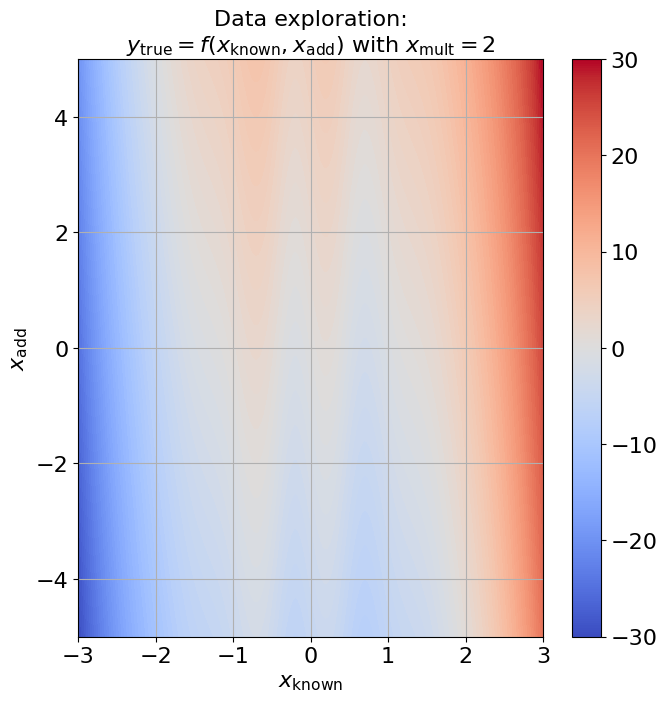

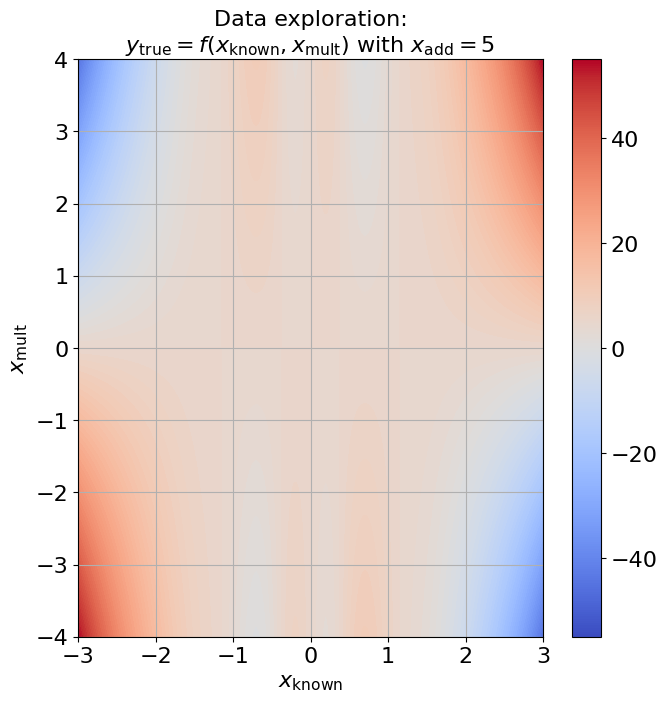

In [110]:
NUM_EXAMPLES_PER_AXIS = 1000

# Create a dataset with x_mult = 2 everywhere.
unique_x_known_values = numpy.linspace(
    -3, 3, num=NUM_EXAMPLES_PER_AXIS, dtype=float
)
unique_x_add_values = numpy.linspace(
    -5, 5, num=NUM_EXAMPLES_PER_AXIS, dtype=float
)
x_known_matrix, x_add_matrix = numpy.meshgrid(
    unique_x_known_values, unique_x_add_values
)
y_matrix = target_function_scenarios1and2(
    x_known_values=x_known_matrix,
    x_mult_values=numpy.full(x_known_matrix.shape, 2.),
    x_add_values=x_add_matrix
)

figure_object, axes_object = pyplot.subplots(
    1, 1, figsize=(FIGURE_WIDTH_INCHES, FIGURE_HEIGHT_INCHES)
)

colour_map_object = pyplot.get_cmap('coolwarm')
colour_norm_object = pyplot.Normalize(
    vmin=-1 * numpy.max(numpy.absolute(y_matrix)),
    vmax=numpy.max(numpy.absolute(y_matrix))
)
axes_object.contourf(
    x_known_matrix, x_add_matrix, y_matrix,
    levels=100,
    cmap=colour_map_object,
    norm=colour_norm_object
)

axes_object.set_xlabel(r'$x_{\text{known}}$')
axes_object.set_ylabel(r'$x_{\text{add}}$')
axes_object.set_title(
    'Data exploration:\n' +
    r'$y_{\text{true}} = f(x_{\text{known}}, x_{\text{add}})$ with $x_{\text{mult}} = 2$'
)
axes_object.grid(True)

plot_colour_bar(
    axes_object_or_matrix=axes_object,
    data_matrix=y_matrix,
    colour_map_object=colour_map_object,
    colour_norm_object=colour_norm_object,
    orientation_string='vertical',
    extend_min=False,
    extend_max=False
)

if SAVE_FIGURES:
    output_file_name = 'scenario2_data_exploration1.jpg'
    print('Saving figure to: "{0:s}"...'.format(output_file_name))
    figure_object.savefig(
        output_file_name, dpi=600, pad_inches=0, bbox_inches='tight'
    )
    pyplot.close(figure_object)

# Create a dataset with x_add = 5 everywhere.
unique_x_known_values = numpy.linspace(
    -3, 3, num=NUM_EXAMPLES_PER_AXIS, dtype=float
)
unique_x_mult_values = numpy.linspace(
    -4, 4, num=NUM_EXAMPLES_PER_AXIS, dtype=float
)
x_known_matrix, x_mult_matrix = numpy.meshgrid(
    unique_x_known_values, unique_x_mult_values
)
y_matrix = target_function_scenarios1and2(
    x_known_values=x_known_matrix,
    x_mult_values=x_mult_matrix,
    x_add_values=numpy.full(x_known_matrix.shape, 5.)
)

figure_object, axes_object = pyplot.subplots(
    1, 1, figsize=(FIGURE_WIDTH_INCHES, FIGURE_HEIGHT_INCHES)
)

colour_map_object = pyplot.get_cmap('coolwarm')
colour_norm_object = pyplot.Normalize(
    vmin=-1 * numpy.max(numpy.absolute(y_matrix)),
    vmax=numpy.max(numpy.absolute(y_matrix))
)
axes_object.contourf(
    x_known_matrix, x_mult_matrix, y_matrix,
    levels=100,
    cmap=colour_map_object,
    norm=colour_norm_object
)

axes_object.set_xlabel(r'$x_{\text{known}}$')
axes_object.set_ylabel(r'$x_{\text{mult}}$')
axes_object.set_title(
    'Data exploration:\n' +
    r'$y_{\text{true}} = f(x_{\text{known}}, x_{\text{mult}})$ with $x_{\text{add}} = 5$'
)
axes_object.grid(True)

plot_colour_bar(
    axes_object_or_matrix=axes_object,
    data_matrix=y_matrix,
    colour_map_object=colour_map_object,
    colour_norm_object=colour_norm_object,
    orientation_string='vertical',
    extend_min=False,
    extend_max=False
)

if SAVE_FIGURES:
    output_file_name = 'scenario2_data_exploration2.jpg'
    print('Saving figure to: "{0:s}"...'.format(output_file_name))
    figure_object.savefig(
        output_file_name, dpi=600, pad_inches=0, bbox_inches='tight'
    )
    pyplot.close(figure_object)

## Train the model with all predictors (but $x_{\textrm{mult}} = 2$ and $x_{\textrm{add}} = 5$ for all training data)

The next code cell trains a BNN/CRPS neural network to predict $y$ from all three predictors; the neural network uses all three predictors, but $x_{\textrm{mult}} = 2$ and but $x_{\textrm{add}} = 5$ everywhere in the training data, so the network has no opportunity to learn anything useful from $x_{\textrm{mult}}$ or $x_{\textrm{add}}$.

In [111]:
NUM_EXAMPLES = 250000

x_known_values = numpy.linspace(-3, 3, num=NUM_EXAMPLES, dtype=float)
training_x_mult_values = numpy.full(NUM_EXAMPLES, 2.)
training_x_add_values = numpy.full(NUM_EXAMPLES, 5.)
training_y_values = target_function_scenarios1and2(
    x_known_values=x_known_values,
    x_mult_values=training_x_mult_values,
    x_add_values=training_x_add_values
)

training_predictor_matrix = numpy.transpose(numpy.vstack(
    [x_known_values, training_x_mult_values, training_x_add_values]
))
training_target_matrix = numpy.expand_dims(training_y_values, axis=-1)

validation_x_mult_values = numpy.random.uniform(
    low=-10., high=10., size=NUM_EXAMPLES
)
validation_x_add_values = numpy.random.uniform(
    low=-10., high=10., size=NUM_EXAMPLES
)
validation_y_values = target_function_scenarios1and2(
    x_known_values=x_known_values,
    x_mult_values=validation_x_mult_values,
    x_add_values=validation_x_add_values
)

validation_predictor_matrix = numpy.transpose(numpy.vstack(
    [x_known_values, validation_x_mult_values, validation_x_add_values]
))
validation_target_matrix = numpy.expand_dims(validation_y_values, axis=-1)

model_object = create_bnn_crps_architecture(
    num_predictors=3,
    num_training_examples=NUM_EXAMPLES,
    num_bayesian_layers=3,
    use_flipout=False
)
model_object.summary()

model_object.fit(
    x=training_predictor_matrix,
    y=training_target_matrix,
    batch_size=100,
    epochs=100,
    initial_epoch=0,
    steps_per_epoch=100,
    shuffle=True,
    verbose=1,
    validation_data=(
        validation_predictor_matrix, validation_target_matrix
    ),
    validation_steps=100
)

Model: "model_17"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 input_18 (InputLayer)       [(None, 3)]               0         
                                                                 
 dense_34 (Dense)            (None, 100)               400       
                                                                 
 leaky_re_lu_68 (LeakyReLU)  (None, 100)               0         
                                                                 
 batch_normalization_68 (Ba  (None, 100)               400       
 tchNormalization)                                               
                                                                 
 dense_35 (Dense)            (None, 100)               10100     
                                                                 
 leaky_re_lu_69 (LeakyReLU)  (None, 100)               0         
                                                          

## Evaluate the model on validation data

The next code cell evaluates the BNN/CRPS neural network on a validation set, where in general, $x_{\textrm{mult}} \neq 2$ and $x_{\textrm{add}} \neq 5$.

As we exit the narrow region of the predictor space that was sampled in the training data (where $x_{\textrm{mult}}$ = 2 and $x_{\textrm{add}}$ = 5), the model makes increasingly wrong predictions but (mostly) with high confidence.  At a certain point (a certain distance away from $x_{\textrm{mult}}$ = 2 and $x_{\textrm{add}}$ = 5, depending on the application), these highly confident wrong predictions would be considered **catastrophic errors**.

Shape of validation_prediction_matrix = (250000, 500)
Have sorted examples into 0 of 10000 bins...
Have sorted examples into 100 of 10000 bins...
Have sorted examples into 200 of 10000 bins...
Have sorted examples into 300 of 10000 bins...
Have sorted examples into 400 of 10000 bins...
Have sorted examples into 500 of 10000 bins...
Have sorted examples into 600 of 10000 bins...
Have sorted examples into 700 of 10000 bins...
Have sorted examples into 800 of 10000 bins...
Have sorted examples into 900 of 10000 bins...
Have sorted examples into 1000 of 10000 bins...
Have sorted examples into 1100 of 10000 bins...
Have sorted examples into 1200 of 10000 bins...
Have sorted examples into 1300 of 10000 bins...
Have sorted examples into 1400 of 10000 bins...
Have sorted examples into 1500 of 10000 bins...
Have sorted examples into 1600 of 10000 bins...
Have sorted examples into 1700 of 10000 bins...
Have sorted examples into 1800 of 10000 bins...
Have sorted examples into 1900 of 10000 bins..

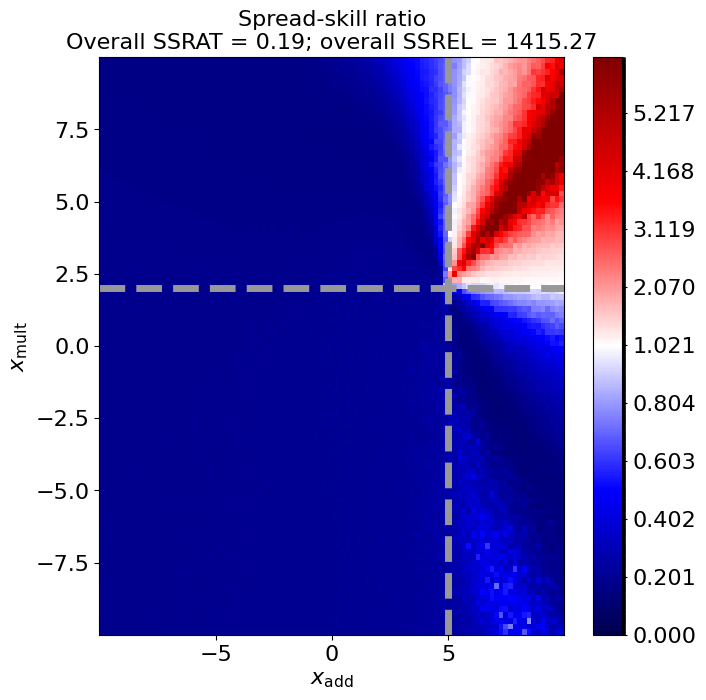

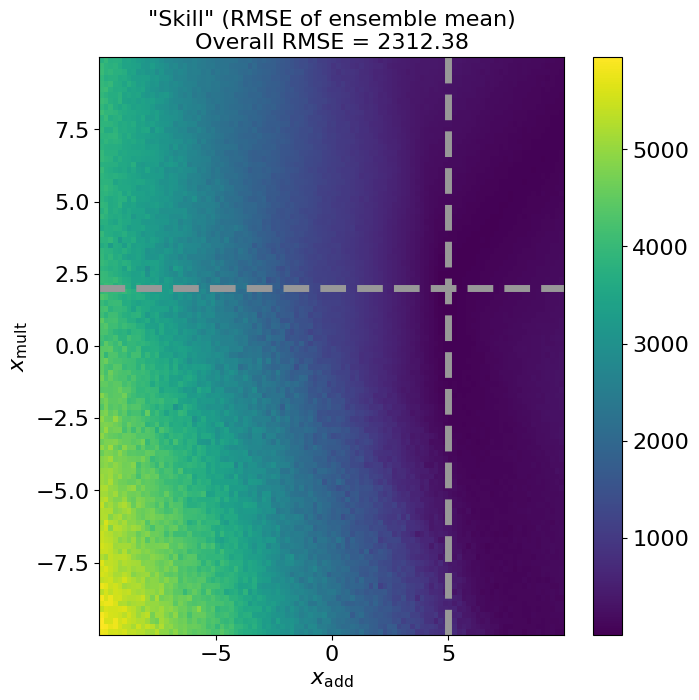

In [112]:
NUM_ITERATIONS = 10
validation_prediction_matrix = numpy.array([])

for i in range(NUM_ITERATIONS):
    new_prediction_matrix = model_object.predict_on_batch(
        validation_predictor_matrix
    )

    if i == 0:
        validation_prediction_matrix = new_prediction_matrix + 0.
    else:
        validation_prediction_matrix = numpy.concatenate(
            [validation_prediction_matrix, new_prediction_matrix], axis=-1
        )

print('Shape of validation_prediction_matrix = {0:s}'.format(
    str(validation_prediction_matrix.shape)
))

(
    binned_skill_matrix, binned_spread_matrix, binned_example_count_matrix,
    x_mult_bin_edges, x_add_bin_edges
) = bin_spread_and_skill_vs_two_vars(
    prediction_matrix=validation_prediction_matrix,
    target_matrix=validation_target_matrix,
    predictor_matrix=validation_predictor_matrix[:, 1:],
    num_bins=100,
    predictor_matrix_for_bin_limits=validation_predictor_matrix[:, 1:]
)

figure_object, axes_object = plot_skill_or_ssrat_vs_two_vars(
    binned_skill_matrix=binned_skill_matrix,
    binned_spread_matrix=binned_spread_matrix,
    binned_example_count_matrix=binned_example_count_matrix,
    x1_bin_edges=x_mult_bin_edges,
    x2_bin_edges=x_add_bin_edges,
    plot_ssrat=True
)
axes_object.set_ylabel(r'$x_{\text{mult}}$')
axes_object.set_xlabel(r'$x_{\text{add}}$')
x_limits = axes_object.get_xlim()
y_limits = axes_object.get_ylim()
axes_object.plot(
    numpy.array(x_limits), numpy.array([2., 2.]),
    color=REFERENCE_LINE_COLOUR,
    linestyle='dashed',
    linewidth=5
)
axes_object.plot(
    numpy.array([5., 5.]), numpy.array(y_limits),
    color=REFERENCE_LINE_COLOUR,
    linestyle='dashed',
    linewidth=5
)

if SAVE_FIGURES:
    output_file_name = 'scenario2_ssrat.jpg'
    print('Saving figure to: "{0:s}"...'.format(output_file_name))
    figure_object.savefig(
        output_file_name, dpi=600, pad_inches=0, bbox_inches='tight'
    )
    pyplot.close(figure_object)

figure_object, axes_object = plot_skill_or_ssrat_vs_two_vars(
    binned_skill_matrix=binned_skill_matrix,
    binned_spread_matrix=binned_spread_matrix,
    binned_example_count_matrix=binned_example_count_matrix,
    x1_bin_edges=x_mult_bin_edges,
    x2_bin_edges=x_add_bin_edges,
    plot_ssrat=False
)
axes_object.set_ylabel(r'$x_{\text{mult}}$')
axes_object.set_xlabel(r'$x_{\text{add}}$')
x_limits = axes_object.get_xlim()
y_limits = axes_object.get_ylim()
axes_object.plot(
    numpy.array(x_limits), numpy.array([2., 2.]),
    color=REFERENCE_LINE_COLOUR,
    linestyle='dashed',
    linewidth=5
)
axes_object.plot(
    numpy.array([5., 5.]), numpy.array(y_limits),
    color=REFERENCE_LINE_COLOUR,
    linestyle='dashed',
    linewidth=5
)

if SAVE_FIGURES:
    output_file_name = 'scenario2_skill.jpg'
    print('Saving figure to: "{0:s}"...'.format(output_file_name))
    figure_object.savefig(
        output_file_name, dpi=600, pad_inches=0, bbox_inches='tight'
    )
    pyplot.close(figure_object)

## Evaluate the model on dummy data ($x_{\textrm{mult}} = 2$ and $x_{\textrm{add}} = 5$ everywhere)

The next code cell evaluates the BNN/CRPS neural network on a dummy validation set, where $x_{\textrm{mult}} = 2$ and $x_{\textrm{add}} = 5$ everywhere.  Thus, the true target function can be written with $x_{\textrm{mult}}$ and $x_{\textrm{add}}$:

$y_{\textrm{true}} = x_{\textrm{mult}}\textrm{ }g(x_{\textrm{known}}) + x_{\textrm{add}}$,

or without them:

$y_{\textrm{true}} = 2\textrm{ }g(x_{\textrm{known}}) + 5$.
<br />
<br />
In this case, both the true function and our neural-network-estimated function depend only on $x_{\textrm{known}}$.  Thus, our neural network is well equipped to handle this dummy dataset and performs much better (compare values of overall SSRAT, SSREL, and RMSE).  Thus, we can conclude that the poor performance on the *real* validation set (above) is caused by $x_{\textrm{mult}}$ deviating from 2, and $x_{\textrm{add}}$ deviating from 5, in the real validation set.

Shape of dummy_prediction_matrix = (250000, 500)
Have sorted examples into 0 of 400 bins...
Have sorted examples into 20 of 400 bins...
Have sorted examples into 40 of 400 bins...
Have sorted examples into 60 of 400 bins...
Have sorted examples into 80 of 400 bins...
Have sorted examples into 100 of 400 bins...
Have sorted examples into 120 of 400 bins...
Have sorted examples into 140 of 400 bins...
Have sorted examples into 160 of 400 bins...
Have sorted examples into 180 of 400 bins...
Have sorted examples into 200 of 400 bins...
Have sorted examples into 220 of 400 bins...
Have sorted examples into 240 of 400 bins...
Have sorted examples into 260 of 400 bins...
Have sorted examples into 280 of 400 bins...
Have sorted examples into 300 of 400 bins...
Have sorted examples into 320 of 400 bins...
Have sorted examples into 340 of 400 bins...
Have sorted examples into 360 of 400 bins...
Have sorted examples into 380 of 400 bins...


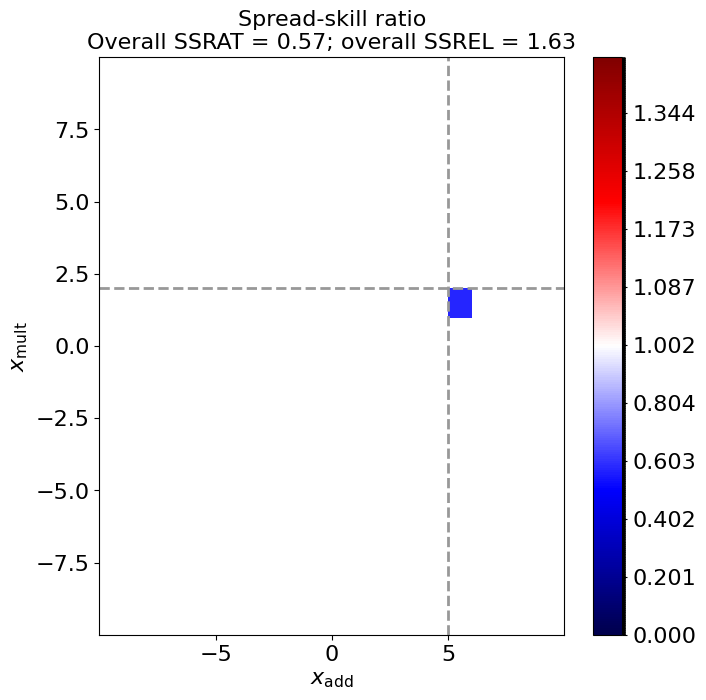

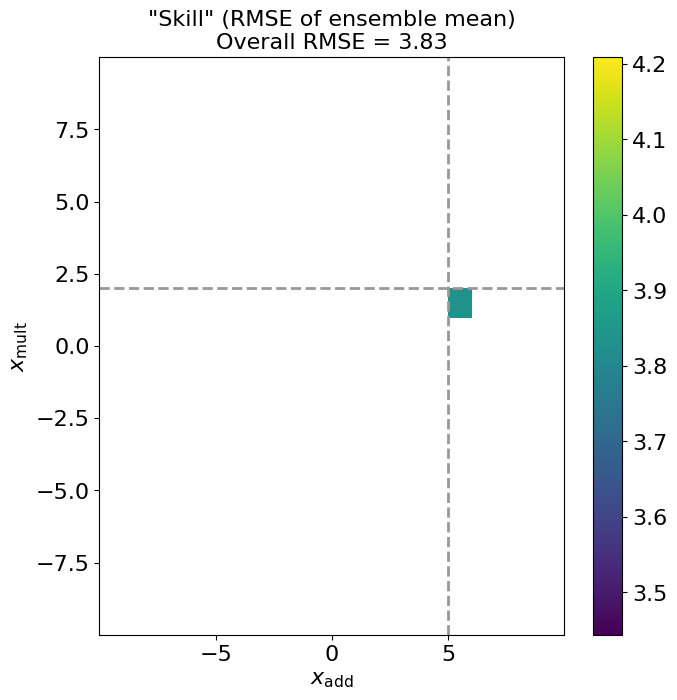

In [113]:
dummy_x_mult_values = numpy.full(NUM_EXAMPLES, 2.)
dummy_x_add_values = numpy.full(NUM_EXAMPLES, 5.)
dummy_y_values = target_function_scenarios1and2(
    x_known_values=x_known_values,
    x_mult_values=dummy_x_mult_values,
    x_add_values=dummy_x_add_values
)

dummy_predictor_matrix = numpy.transpose(
    numpy.vstack([x_known_values, dummy_x_mult_values, dummy_x_add_values])
)
dummy_target_matrix = numpy.expand_dims(dummy_y_values, axis=-1)

dummy_prediction_matrix = numpy.array([])

for i in range(NUM_ITERATIONS):
    new_prediction_matrix = model_object.predict_on_batch(
        dummy_predictor_matrix
    )

    if i == 0:
        dummy_prediction_matrix = new_prediction_matrix + 0.
    else:
        dummy_prediction_matrix = numpy.concatenate(
            [dummy_prediction_matrix, new_prediction_matrix], axis=-1
        )

print('Shape of dummy_prediction_matrix = {0:s}'.format(
    str(dummy_prediction_matrix.shape)
))

(
    binned_skill_matrix, binned_spread_matrix, binned_example_count_matrix,
    x_mult_bin_edges, x_add_bin_edges
) = bin_spread_and_skill_vs_two_vars(
    prediction_matrix=dummy_prediction_matrix,
    target_matrix=dummy_target_matrix,
    predictor_matrix=dummy_predictor_matrix[:, 1:],
    num_bins=20,
    predictor_matrix_for_bin_limits=validation_predictor_matrix[:, 1:]
)

figure_object, axes_object = plot_skill_or_ssrat_vs_two_vars(
    binned_skill_matrix=binned_skill_matrix,
    binned_spread_matrix=binned_spread_matrix,
    binned_example_count_matrix=binned_example_count_matrix,
    x1_bin_edges=x_mult_bin_edges,
    x2_bin_edges=x_add_bin_edges,
    plot_ssrat=True
)
axes_object.set_ylabel(r'$x_{\text{mult}}$')
axes_object.set_xlabel(r'$x_{\text{add}}$')
x_limits = axes_object.get_xlim()
y_limits = axes_object.get_ylim()
axes_object.plot(
    numpy.array(x_limits), numpy.array([2., 2.]),
    color=REFERENCE_LINE_COLOUR,
    linestyle='dashed',
    linewidth=REFERENCE_LINE_WIDTH
)
axes_object.plot(
    numpy.array([5., 5.]), numpy.array(y_limits),
    color=REFERENCE_LINE_COLOUR,
    linestyle='dashed',
    linewidth=REFERENCE_LINE_WIDTH
)

figure_object, axes_object = plot_skill_or_ssrat_vs_two_vars(
    binned_skill_matrix=binned_skill_matrix,
    binned_spread_matrix=binned_spread_matrix,
    binned_example_count_matrix=binned_example_count_matrix,
    x1_bin_edges=x_mult_bin_edges,
    x2_bin_edges=x_add_bin_edges,
    plot_ssrat=False
)
axes_object.set_ylabel(r'$x_{\text{mult}}$')
axes_object.set_xlabel(r'$x_{\text{add}}$')
x_limits = axes_object.get_xlim()
y_limits = axes_object.get_ylim()
axes_object.plot(
    numpy.array(x_limits), numpy.array([2., 2.]),
    color=REFERENCE_LINE_COLOUR,
    linestyle='dashed',
    linewidth=REFERENCE_LINE_WIDTH
)
axes_object.plot(
    numpy.array([5., 5.]), numpy.array(y_limits),
    color=REFERENCE_LINE_COLOUR,
    linestyle='dashed',
    linewidth=REFERENCE_LINE_WIDTH
)

# Scenario 3: Missing basis vector in training data

In this scenario, the target value is still a function of both $x_1$ and $x_2$ -- and appropriately, the model uses both $x_1$ and $x_2$ as predictors.
<br />
$y_{\textrm{true}} = f(x_1, x_2)$
<br />
$\vec{y}_{\textrm{pred}} = \hat{f}(x_1, x_2)$
<br />
<br />
The range of possible values for $x_1$ is $-7\ldots+7$; the range of possible values for $x_2$ is also $-7\ldots+7$.  In the model's training set, both $x_1$ and $x_2$ span the full range of possible values -- so we should be good, right?
<br />
<br />
Wrong!  Even though the training dataset spans the full *univariate* space for each predictor, it does not span the full *multivariate* space.  Specifically, the training dataset contains no examples with $x_1 + x_2 > 7$ or $x_1 + x_2 < -7$, even though the range of possible values for $x_1 + x_2$ is $-14\ldots+14$.  In other words, the training dataset does not sample adequately along the **basis vector** $x_1 + x_2$.  At inference time, when we encounter a training sample with $x_1 + x_2 \approxeq -14$ or $x_1 + x_2 \approxeq 14$, it will be far **out-of-sample** with respect to the training data, even if both the individual variables are in sample.

## Data exploration

Specifically, $y_{\textrm{true}} = A(x_1, x_2) b(x_1, x_2)$, where $A$ is the amplitude-envelope function and $b$ is the base function.

$b = \textrm{sin}(3x_1) \textrm{cos}(3x_2) + 0.2\textrm{sin}(5 x_1 x_2)$
<br />
$A = 1 + \frac{x_1^2 + x_2^2}{2}$
<br />
<br />
The next code cell shows the above relationship under two scenarios:
 - When $x_1 + x_2$ covers the full range of possible values ($-14\ldots+14$)
 - When $x_1 + x_2$ is limited to $-7\ldots+7$

<ipython-input-133-51623ad97bba>:26: UserWarning: The following kwargs were not used by contour: 'linestyle', 'linewidth'
  contour_handle = axes_object.contour(
<ipython-input-133-51623ad97bba>:90: UserWarning: The following kwargs were not used by contour: 'linestyle', 'linewidth'
  contour_handle = axes_object.contour(


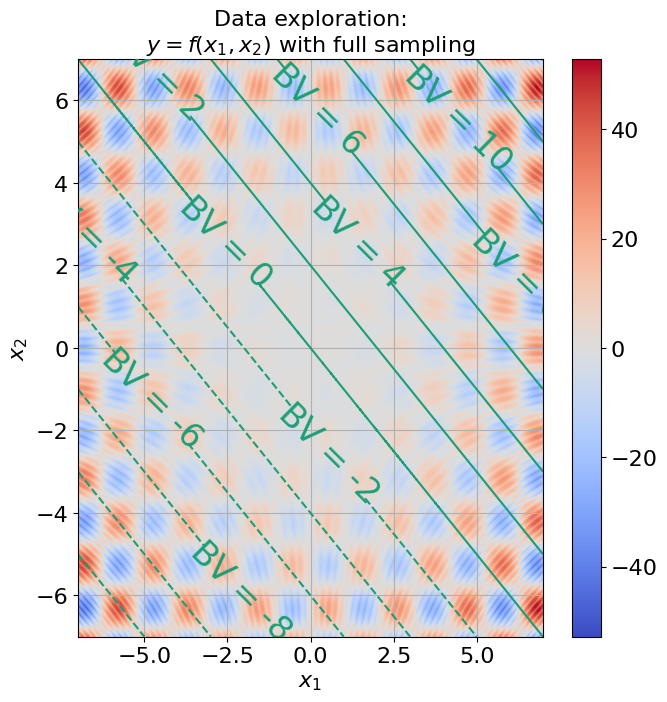

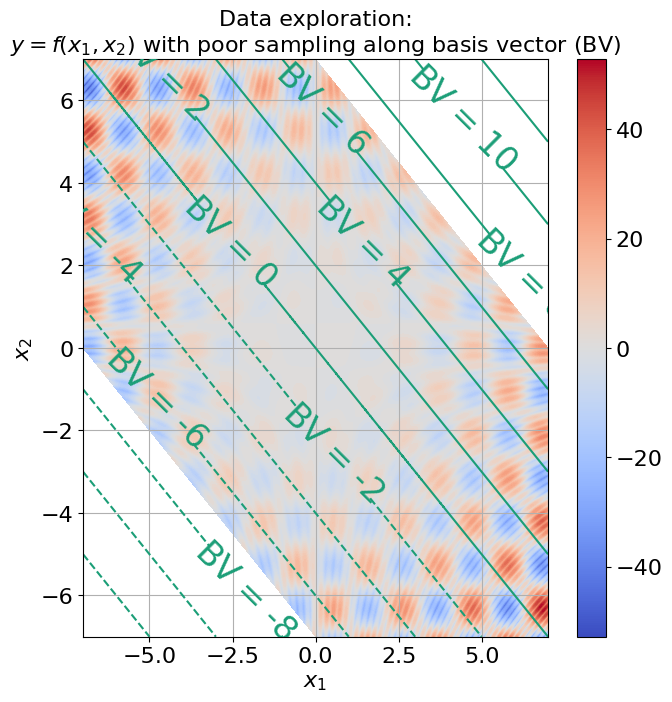

In [133]:
NUM_EXAMPLES_PER_AXIS = 1000
BASIS_VECTOR_COLOUR = numpy.array([27, 158, 119], dtype=float) / 255

# Create a dataset with both x_1 and x_2 varying from -5...5.
unique_x1_values = numpy.linspace(-7, 7, num=NUM_EXAMPLES_PER_AXIS, dtype=float)
unique_x2_values = numpy.linspace(-7, 7, num=NUM_EXAMPLES_PER_AXIS, dtype=float)
x1_matrix, x2_matrix = numpy.meshgrid(unique_x1_values, unique_x2_values)
y_matrix = target_function_scenario3(x1_values=x1_matrix, x2_values=x2_matrix)
basis_vector_matrix = x1_matrix + x2_matrix

figure_object, axes_object = pyplot.subplots(
    1, 1, figsize=(FIGURE_WIDTH_INCHES, FIGURE_HEIGHT_INCHES)
)

colour_map_object = pyplot.get_cmap('coolwarm')
colour_norm_object = pyplot.Normalize(
    vmin=-1 * numpy.max(numpy.absolute(y_matrix)),
    vmax=numpy.max(numpy.absolute(y_matrix))
)
axes_object.contourf(
    x1_matrix, x2_matrix, y_matrix,
    levels=100,
    cmap=colour_map_object,
    norm=colour_norm_object
)
contour_handle = axes_object.contour(
    x1_matrix, x2_matrix, basis_vector_matrix,
    levels=numpy.linspace(-14, 14, num=15, dtype=float),
    colors=BASIS_VECTOR_COLOUR,
    linestyle='solid',
    linewidth=5
)
axes_object.clabel(
    contour_handle,
    inline=True,
    fontsize=1.5 * DEFAULT_FONT_SIZE,
    colors=tuple([BASIS_VECTOR_COLOUR] * 15),
    fmt=lambda val: f'BV = {val:.0f}',
    inline_spacing=0
)

axes_object.set_xlabel(r'$x_1$')
axes_object.set_ylabel(r'$x_2$')
axes_object.set_title(
    'Data exploration:\n' +
    r'$y = f(x_1, x_2)$ with full sampling'
)
axes_object.grid(True)

plot_colour_bar(
    axes_object_or_matrix=axes_object,
    data_matrix=y_matrix,
    colour_map_object=colour_map_object,
    colour_norm_object=colour_norm_object,
    orientation_string='vertical',
    extend_min=False,
    extend_max=False
)

if SAVE_FIGURES:
    output_file_name = 'scenario3_data_exploration1.jpg'
    print('Saving figure to: "{0:s}"...'.format(output_file_name))
    figure_object.savefig(
        output_file_name, dpi=600, pad_inches=0, bbox_inches='tight'
    )
    pyplot.close(figure_object)

# Create a similar dataset but with poor sampling along the basis vector
# x_1 + x_2.
y_matrix[x1_matrix + x2_matrix > 7] = numpy.nan
y_matrix[x1_matrix + x2_matrix < -7] = numpy.nan
y_matrix = numpy.ma.masked_where(numpy.isnan(y_matrix), y_matrix)

figure_object, axes_object = pyplot.subplots(
    1, 1, figsize=(FIGURE_WIDTH_INCHES, FIGURE_HEIGHT_INCHES)
)

colour_map_object = pyplot.get_cmap('coolwarm').copy()
colour_map_object.set_bad(numpy.full(3, 152. / 255))
colour_norm_object = pyplot.Normalize(
    vmin=-1 * numpy.nanmax(numpy.absolute(y_matrix)),
    vmax=numpy.nanmax(numpy.absolute(y_matrix))
)
axes_object.contourf(
    x1_matrix, x2_matrix, y_matrix,
    levels=100,
    cmap=colour_map_object,
    norm=colour_norm_object
)
contour_handle = axes_object.contour(
    x1_matrix, x2_matrix, basis_vector_matrix,
    levels=numpy.linspace(-14, 14, num=15, dtype=float),
    colors=BASIS_VECTOR_COLOUR,
    linestyle='solid',
    linewidth=5
)
axes_object.clabel(
    contour_handle,
    inline=True,
    fontsize=1.5 * DEFAULT_FONT_SIZE,
    colors=tuple([BASIS_VECTOR_COLOUR] * 15),
    fmt=lambda val: f'BV = {val:.0f}',
    inline_spacing=0
)

axes_object.set_xlabel(r'$x_1$')
axes_object.set_ylabel(r'$x_2$')
axes_object.set_title(
    'Data exploration:\n' +
    r'$y = f(x_1, x_2)$ with poor sampling along basis vector (BV)'
)
axes_object.grid(True)

plot_colour_bar(
    axes_object_or_matrix=axes_object,
    data_matrix=y_matrix,
    colour_map_object=colour_map_object,
    colour_norm_object=colour_norm_object,
    orientation_string='vertical',
    extend_min=False,
    extend_max=False
)

if SAVE_FIGURES:
    output_file_name = 'scenario3_data_exploration2.jpg'
    print('Saving figure to: "{0:s}"...'.format(output_file_name))
    figure_object.savefig(
        output_file_name, dpi=600, pad_inches=0, bbox_inches='tight'
    )
    pyplot.close(figure_object)

## Train the model with poorly sampled basis vector

The next code cell trains a BNN/CRPS neural network to predict $y$ from $x_1$ and $x_2$; the neural network uses both $x_1$ and $x_2$ as predictors, but $\lvert x_1 + x_2 \rvert < 7$ everywhere in the training data, so the network has no opportunity to learn what happens when $\lvert x_1 + x_2 \rvert \in \left[ 7, 14 \right]$.

In [115]:
NUM_EXAMPLES_PER_AXIS = 500

unique_x1_values = numpy.linspace(-7, 7, num=NUM_EXAMPLES_PER_AXIS, dtype=float)
unique_x2_values = numpy.linspace(-7, 7, num=NUM_EXAMPLES_PER_AXIS, dtype=float)
x1_matrix, x2_matrix = numpy.meshgrid(unique_x1_values, unique_x2_values)

all_x1_values = numpy.ravel(x1_matrix)
all_x2_values = numpy.ravel(x2_matrix)
all_y_values = target_function_scenario3(
    x1_values=all_x1_values, x2_values=all_x2_values
)

first_bad_flags = all_x1_values + all_x2_values > 7
second_bad_flags = all_x1_values + all_x2_values < -7
training_indices = numpy.where(
    numpy.invert(numpy.logical_or(first_bad_flags, second_bad_flags))
)[0]

training_x1_values = all_x1_values[training_indices]
training_x2_values = all_x2_values[training_indices]
training_y_values = all_y_values[training_indices]
training_predictor_matrix = numpy.transpose(
    numpy.vstack([training_x1_values, training_x2_values])
)
training_target_matrix = numpy.expand_dims(training_y_values, axis=-1)

validation_predictor_matrix = numpy.transpose(
    numpy.vstack([all_x1_values, all_x2_values])
)
validation_target_matrix = numpy.expand_dims(all_y_values, axis=-1)

model_object = create_bnn_crps_architecture(
    num_predictors=2,
    num_training_examples=training_predictor_matrix.shape[0],
    num_bayesian_layers=3,
    use_flipout=False
)
model_object.summary()

model_object.fit(
    x=training_predictor_matrix,
    y=training_target_matrix,
    batch_size=int(numpy.round(
        float(training_predictor_matrix.shape[0]) / 100
    )),
    epochs=25,
    initial_epoch=0,
    steps_per_epoch=100,
    shuffle=True,
    verbose=1,
    validation_data=(validation_predictor_matrix, validation_target_matrix),
    validation_steps=100
)

Model: "model_18"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 input_19 (InputLayer)       [(None, 2)]               0         
                                                                 
 dense_36 (Dense)            (None, 100)               300       
                                                                 
 leaky_re_lu_72 (LeakyReLU)  (None, 100)               0         
                                                                 
 batch_normalization_72 (Ba  (None, 100)               400       
 tchNormalization)                                               
                                                                 
 dense_37 (Dense)            (None, 100)               10100     
                                                                 
 leaky_re_lu_73 (LeakyReLU)  (None, 100)               0         
                                                          

## Evaluate the model on validation data (basis vector spans full range)

The next code cell evaluates the BNN/CRPS neural network on a validation set, where $\lvert x_1 + x_2 \rvert$ ranges all the way up to 14.

As $\lvert x_1 + x_2 \rvert$ increases beyond 7, the model's error (RMSE of the ensemble mean) increases, but spread-skill ratio decreases.  In other words, the model makes increasingly wrong predictions but with high confidence.  At a certain point (a certain distance of $\lvert x_1 + x_2 \rvert$ away from 7, depending on the application), these highly confident wrong predictions would be considered **catastrophic errors**.

Shape of validation_prediction_matrix = (250000, 500)
Have sorted examples into 0 of 10000 bins...
Have sorted examples into 100 of 10000 bins...
Have sorted examples into 200 of 10000 bins...
Have sorted examples into 300 of 10000 bins...
Have sorted examples into 400 of 10000 bins...
Have sorted examples into 500 of 10000 bins...
Have sorted examples into 600 of 10000 bins...
Have sorted examples into 700 of 10000 bins...
Have sorted examples into 800 of 10000 bins...
Have sorted examples into 900 of 10000 bins...
Have sorted examples into 1000 of 10000 bins...
Have sorted examples into 1100 of 10000 bins...
Have sorted examples into 1200 of 10000 bins...
Have sorted examples into 1300 of 10000 bins...
Have sorted examples into 1400 of 10000 bins...
Have sorted examples into 1500 of 10000 bins...
Have sorted examples into 1600 of 10000 bins...
Have sorted examples into 1700 of 10000 bins...
Have sorted examples into 1800 of 10000 bins...
Have sorted examples into 1900 of 10000 bins..

<ipython-input-134-ffe21d35c60d>:49: UserWarning: The following kwargs were not used by contour: 'linestyle'
  contour_handle = axes_object.contour(
<ipython-input-134-ffe21d35c60d>:89: UserWarning: The following kwargs were not used by contour: 'linestyle'
  contour_handle = axes_object.contour(


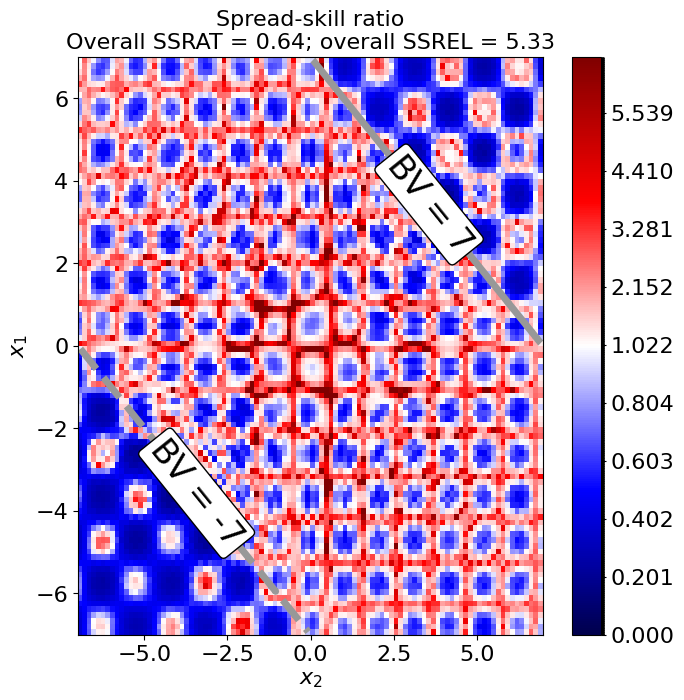

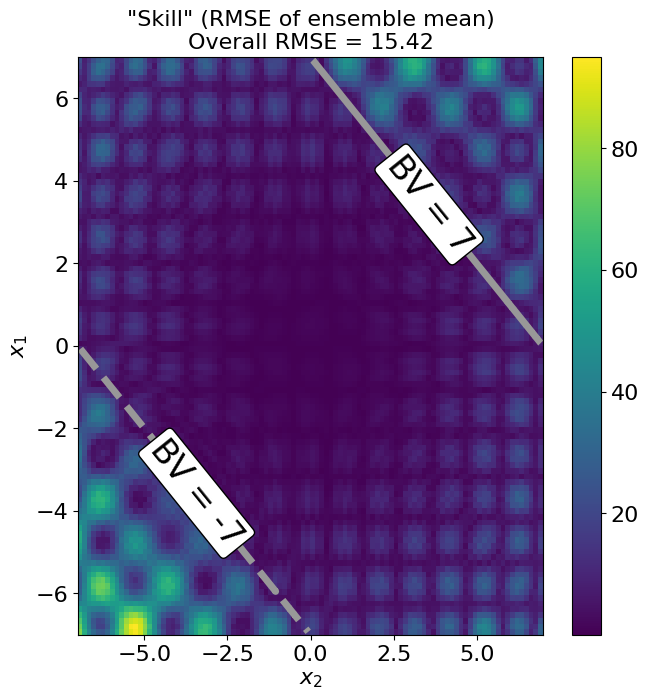

In [134]:
NUM_ITERATIONS = 10
CONTOUR_LINE_COLOUR = numpy.full(3, 152. / 255)
TEXT_COLOUR = numpy.full(3, 0.)

validation_prediction_matrix = numpy.array([])

for i in range(NUM_ITERATIONS):
    new_prediction_matrix = model_object.predict_on_batch(
        validation_predictor_matrix
    )

    if i == 0:
        validation_prediction_matrix = new_prediction_matrix + 0.
    else:
        validation_prediction_matrix = numpy.concatenate(
            [validation_prediction_matrix, new_prediction_matrix], axis=-1
        )

print('Shape of validation_prediction_matrix = {0:s}'.format(
    str(validation_prediction_matrix.shape)
))

(
    binned_skill_matrix, binned_spread_matrix, binned_example_count_matrix,
    x1_bin_edges, x2_bin_edges
) = bin_spread_and_skill_vs_two_vars(
    prediction_matrix=validation_prediction_matrix,
    target_matrix=validation_target_matrix,
    predictor_matrix=validation_predictor_matrix,
    num_bins=100,
    predictor_matrix_for_bin_limits=validation_predictor_matrix
)

figure_object, axes_object = plot_skill_or_ssrat_vs_two_vars(
    binned_skill_matrix=binned_skill_matrix,
    binned_spread_matrix=binned_spread_matrix,
    binned_example_count_matrix=binned_example_count_matrix,
    x1_bin_edges=x1_bin_edges,
    x2_bin_edges=x2_bin_edges,
    plot_ssrat=True
)
axes_object.set_ylabel(r'$x_1$')
axes_object.set_xlabel(r'$x_2$')

x1_bin_centers = (x1_bin_edges[:-1] + x1_bin_edges[1:]) / 2.
x2_bin_centers = (x2_bin_edges[:-1] + x2_bin_edges[1:]) / 2.
x1_matrix, x2_matrix = numpy.meshgrid(x1_bin_centers, x2_bin_centers)
basis_vector_matrix = x1_matrix + x2_matrix
contour_handle = axes_object.contour(
    x1_matrix, x2_matrix, basis_vector_matrix,
    levels=numpy.array([-7., 7.]),
    colors=CONTOUR_LINE_COLOUR,
    linestyle='solid',
    linewidths=5
)
label_handles = axes_object.clabel(
    contour_handle,
    inline=True,
    fontsize=1.5 * DEFAULT_FONT_SIZE,
    colors=tuple([TEXT_COLOUR] * 2),
    fmt=lambda val: f'BV = {val:.0f}',
    inline_spacing=0
)

for text_handle in label_handles:
    text_handle.set_bbox(dict(
        boxstyle='round, pad=0.15', facecolor='white', edgecolor='black'
    ))

if SAVE_FIGURES:
    output_file_name = 'scenario3_ssrat.jpg'
    print('Saving figure to: "{0:s}"...'.format(output_file_name))
    figure_object.savefig(
        output_file_name, dpi=600, pad_inches=0, bbox_inches='tight'
    )
    pyplot.close(figure_object)

figure_object, axes_object = plot_skill_or_ssrat_vs_two_vars(
    binned_skill_matrix=binned_skill_matrix,
    binned_spread_matrix=binned_spread_matrix,
    binned_example_count_matrix=binned_example_count_matrix,
    x1_bin_edges=x1_bin_edges,
    x2_bin_edges=x2_bin_edges,
    plot_ssrat=False
)
axes_object.set_ylabel(r'$x_1$')
axes_object.set_xlabel(r'$x_2$')

contour_handle = axes_object.contour(
    x1_matrix, x2_matrix, basis_vector_matrix,
    levels=numpy.array([-7., 7.]),
    colors=CONTOUR_LINE_COLOUR,
    linestyle='solid',
    linewidths=5
)
label_handles = axes_object.clabel(
    contour_handle,
    inline=True,
    fontsize=1.5 * DEFAULT_FONT_SIZE,
    colors=tuple([TEXT_COLOUR] * 2),
    fmt=lambda val: f'BV = {val:.0f}',
    inline_spacing=0
)

for text_handle in label_handles:
    text_handle.set_bbox(dict(
        boxstyle='round, pad=0.15', facecolor='white', edgecolor='black'
    ))

if SAVE_FIGURES:
    output_file_name = 'scenario3_skill.jpg'
    print('Saving figure to: "{0:s}"...'.format(output_file_name))
    figure_object.savefig(
        output_file_name, dpi=600, pad_inches=0, bbox_inches='tight'
    )
    pyplot.close(figure_object)

## Evaluate the model on dummy data (poorly sampled basis vector again)

The next code cell evaluates the BNN/CRPS neural network on a dummy validation set, where $\lvert x_1 + x_2 \rvert < 7$ everywhere.
<br />
<br />
In this case, both the true function and our neural-network-estimated function are not affected by $\lvert x_1 + x_2 \rvert$ values above 7.  Thus, our neural network is well equipped to handle this dummy dataset and performs much better (compare values of overall SSRAT, SSREL, and RMSE).  Thus, we can conclude that the poor performance on the *real* validation set (above) is caused by $\lvert x_1 + x_2 \rvert$ exceeding 7 in the real validation set.

Shape of dummy_prediction_matrix = (250000, 500)
Have sorted examples into 0 of 10000 bins...
Have sorted examples into 100 of 10000 bins...
Have sorted examples into 200 of 10000 bins...
Have sorted examples into 300 of 10000 bins...
Have sorted examples into 400 of 10000 bins...
Have sorted examples into 500 of 10000 bins...
Have sorted examples into 600 of 10000 bins...
Have sorted examples into 700 of 10000 bins...
Have sorted examples into 800 of 10000 bins...
Have sorted examples into 900 of 10000 bins...
Have sorted examples into 1000 of 10000 bins...
Have sorted examples into 1100 of 10000 bins...
Have sorted examples into 1200 of 10000 bins...
Have sorted examples into 1300 of 10000 bins...
Have sorted examples into 1400 of 10000 bins...
Have sorted examples into 1500 of 10000 bins...
Have sorted examples into 1600 of 10000 bins...
Have sorted examples into 1700 of 10000 bins...
Have sorted examples into 1800 of 10000 bins...
Have sorted examples into 1900 of 10000 bins...
Hav

Text(0.5, 0, '$x_2$')

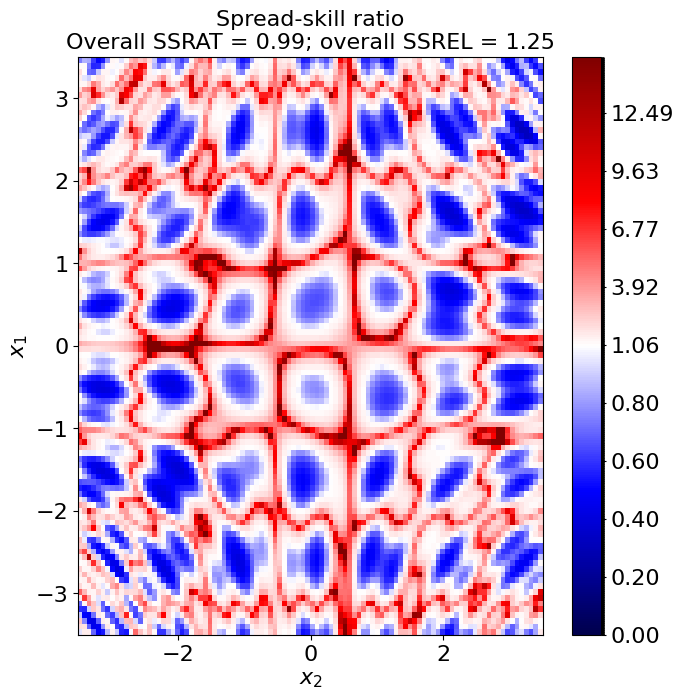

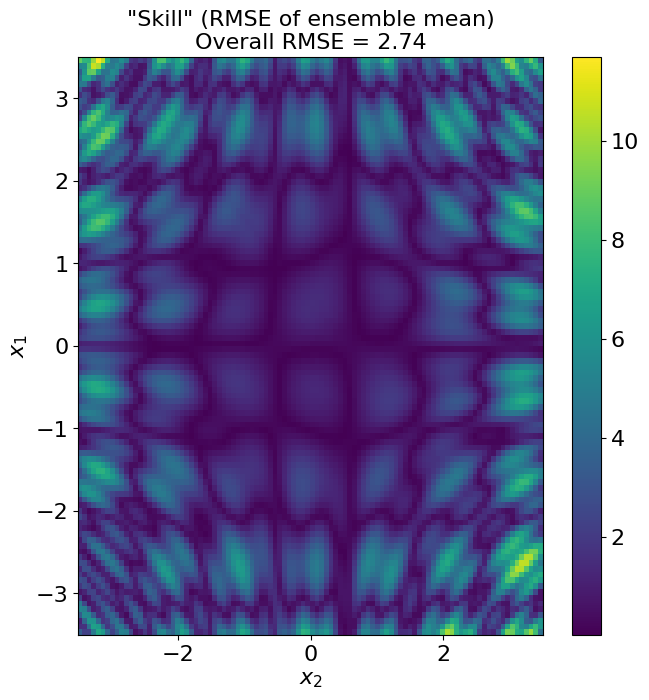

In [135]:
NUM_EXAMPLES_PER_AXIS = 500

unique_x1_values = numpy.linspace(-3.5, 3.5, num=NUM_EXAMPLES_PER_AXIS, dtype=float)
unique_x2_values = numpy.linspace(-3.5, 3.5, num=NUM_EXAMPLES_PER_AXIS, dtype=float)
x1_matrix, x2_matrix = numpy.meshgrid(unique_x1_values, unique_x2_values)

all_x1_values = numpy.ravel(x1_matrix)
all_x2_values = numpy.ravel(x2_matrix)
all_y_values = target_function_scenario3(
    x1_values=all_x1_values, x2_values=all_x2_values
)

dummy_predictor_matrix = numpy.transpose(
    numpy.vstack([all_x1_values, all_x2_values])
)
dummy_target_matrix = numpy.expand_dims(all_y_values, axis=-1)

dummy_prediction_matrix = numpy.array([])

for i in range(NUM_ITERATIONS):
    new_prediction_matrix = model_object.predict_on_batch(
        dummy_predictor_matrix
    )

    if i == 0:
        dummy_prediction_matrix = new_prediction_matrix + 0.
    else:
        dummy_prediction_matrix = numpy.concatenate(
            [dummy_prediction_matrix, new_prediction_matrix], axis=-1
        )

print('Shape of dummy_prediction_matrix = {0:s}'.format(
    str(dummy_prediction_matrix.shape)
))

(
    binned_skill_matrix, binned_spread_matrix, binned_example_count_matrix,
    x1_bin_edges, x2_bin_edges
) = bin_spread_and_skill_vs_two_vars(
    prediction_matrix=dummy_prediction_matrix,
    target_matrix=dummy_target_matrix,
    predictor_matrix=dummy_predictor_matrix,
    num_bins=100,
    predictor_matrix_for_bin_limits=dummy_predictor_matrix
)

figure_object, axes_object = plot_skill_or_ssrat_vs_two_vars(
    binned_skill_matrix=binned_skill_matrix,
    binned_spread_matrix=binned_spread_matrix,
    binned_example_count_matrix=binned_example_count_matrix,
    x1_bin_edges=x1_bin_edges,
    x2_bin_edges=x2_bin_edges,
    plot_ssrat=True
)
axes_object.set_ylabel(r'$x_1$')
axes_object.set_xlabel(r'$x_2$')

figure_object, axes_object = plot_skill_or_ssrat_vs_two_vars(
    binned_skill_matrix=binned_skill_matrix,
    binned_spread_matrix=binned_spread_matrix,
    binned_example_count_matrix=binned_example_count_matrix,
    x1_bin_edges=x1_bin_edges,
    x2_bin_edges=x2_bin_edges,
    plot_ssrat=False
)
axes_object.set_ylabel(r'$x_1$')
axes_object.set_xlabel(r'$x_2$')